# 📦 **Shanta Gold Leaching Model Development Notebook**

This notebook supports the structured development, validation, and tuning of gold dissolution and cyanide consumption models for Shanta Gold's processing circuit.

---

## 📂 Load Data and Setup
#### **❓What we are doing:**
We're importing required libraries, loading raw plant data from Excel, and cleaning the column names for consistent use throughout the notebook. We also export the cleaned dataset to .pkl and .csv formats to support efficient access in later steps.

#### **❗Why this matters:**
Clean and standardised column names are essential for reproducible modelling. Saving the data ensures we avoid repeating the cleaning step later.

In [540]:
import re
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from typing import Callable, List, Tuple
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Ridge, Lasso
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize_scalar

df_site = pd.read_excel("site_leaching_data.xlsx", sheet_name=0)

# Clean column names: strip whitespace and unify format
def clean_column_name(col):
	col = col.strip()
	col = re.sub(r'\s+', '_', col)
	col = re.sub(r'[^\w\d_]', '', col)
	# Remove double underscores
	col = re.sub(r'__+', '_', col)
	# Convert to lowercase
	col = col.lower()
	# Capitablize first letter and each letter after an underscore
	col = col.replace('_', ' ').title().replace(' ', '_')
	return col

df_site.columns = [clean_column_name(col) for col in df_site.columns]

# Save cleaned DataFrame to pickle for future use
df_site.to_pickle("cleaned_site_data.pkl")

# Save cleaned DataFrame to csv for easier access
df_site.to_csv("cleaned_site_data.csv", index=False)

#### **🧩 Outcome:**
The data was successfully loaded, cleaned, and saved to two formats (cleaned_site_data.pkl and cleaned_site_data.csv). We’re now ready to explore the dataset further.

## 🔍 Dataset Summary
**What we are doing:**
We’re performing a high-level summary of the dataset to understand its structure—how many records and features it contains—and to preview the value ranges and distributions of key fields.

**Why this matters:**
This step helps verify data completeness and highlights any early issues like missing values or outliers before more detailed modelling.

In [541]:
print("Rows:", df_site.shape[0])
print("Columns:", df_site.shape[1])
df_site.describe(include='all').T.head()

Rows: 334
Columns: 103


,count,mean,min,25%,50%,75%,max,std
Date,334,2024-11-14 12:00:00,2024-06-01 00:00:00,2024-08-23 06:00:00,2024-11-14 12:00:00,2025-02-05 18:00:00,2025-04-30 00:00:00,NaN
Leach_Feed_Throughput_M3Hr,334.0,149.069628,82.251427,139.231245,143.532969,149.047893,290.862774,25.847754
Leach_Feed_Throughput_M3Day,334.0,3361.034649,947.769899,3250.077557,3401.969683,3551.990909,6206.879399,668.362032
Percentsolids,334.0,49.118174,31.4,49.131159,50.0,51.072917,55.208333,4.060619
Leach_Feed_Grade_Au_Gt_Ds,334.0,2.098886,0.0,1.76,2.155,2.44,4.13,0.623796


#### **🧩 Outcome:**
The dataset contains 334 rows and 103 columns. Key numeric fields such as throughput, solids percentage, and gold feed grade appear within expected ranges.

#### **📌 So what?**
This gives us confidence to proceed. However, we’ll need to carefully handle potential missing values or outliers during preprocessing for modelling accuracy.

## Define constants and parameters
#### **❓What we are doing:**
Defining operational and chemical constants for the leaching circuit. These include tank volumes, pulp densities, cyanide decay factors, particle size thresholds, and other assumed or measured values used throughout the model.

#### **❗Why this matters:**
These constants underpin all subsequent calculations. They act as parameters for estimating cyanide consumption, simulating mass balance, and setting up fallback logic.

In [542]:
# Define default colours for plots and visualisations
def_colours = ["#0099CC", "#003366", "#BDDB94", "#BBBDC0", "#6CBCE3",
			   "#A6D2EC", "#C00000", "#FFC000", "#00B050", "#7030A0"] 

# Define static tank volumes
tank_config = {
	"Cyanide_Profile_Ppm_Leach_Tank_1": 1000,
	"Cyanide_Profile_Ppm_Leach_Tank_2": 1000,
	"Cyanide_Profile_Ppm_Cil_Tank_1": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_2": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_3": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_4": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_5": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_6": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_7": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_8": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_9": 250,
}
total_circuit_volume = sum(tank_config.values())
cn_decay_factor = 0.85  			# % CN that remains from one tank to the next in the series
max_nacn_drawdown = 12
d = 20 								# ore particle size µm
particle_size_threshold = 50 		# µm
locked_gold_threshold = 0.02 		# 5%
liberation_fraction = 1 - locked_gold_threshold
density = 2.7  						# assumed pulp density in kg/L
pulp_density = 1.5  				# kg/L
constant_pulp_density = True 		# use constant pulp density based on ore type

total_residence_time = 30 				# hours
outlier_thresholds = {
	'Nacn_Used_T': (0, 10),  					# t NaCN used per day
	'Daily_Nacn_Consumption_Kgt': (0, 10),		# kg NaCN consumed per tonne of ore
	'MTD_Nacn_Consumption_Kgt': (0, 10)			# kg NaCN consumed per tonne of ore
}
solid_density = 2.7  	# t/m³
liquid_density = 1.0  	# t/m³ (mostly water, even after dilution)

#### **🧩 Outcome:**
Parameters and thresholds are now clearly defined and centralised. These values can be referenced or adjusted as needed across the model.

#### **📌 So what?**
These definitions help ensure that all downstream steps are consistent and grounded in physically meaningful assumptions.

## 🧹 Cleanse the Dataset
#### **❓What we are doing:**
We're cleansing and transforming the raw dataset into a version ready for modelling. This includes:
* Imputing missing values (e.g. CN ppm and oxygen),
* Estimating cyanide dosing from tank concentrations and feed volumes,
* Interpolating warehouse drawdowns and calculating kg/t usage,
* Generating rolling and month-to-date (MTD) metrics,
* Creating a blended final consumption estimate for model use.

#### **❗Why this matters:**
Real-world data often has missing values, outliers, and inconsistencies. This step standardises the inputs and provides robust estimates that feed directly into modelling and diagnostic steps.

In [543]:
def cleanse_data(df):
	"""
	Revised data cleansing function that:
	- Interpolates oxygen sensor values
	- Flags CN dosing tanks
	- Filters outliers in NaCN usage (≤ 6 t/day)
	- Imputes missing NaCN values safely
	- Calculates estimated CN consumption from tank concentration + feed volume
	- Provides both cumulative rolling and true calendar MTD NaCN metrics
	- Outputs final blended daily CN consumption estimate (volume-balanced)
	"""

	# --- Identify relevant columns ---
	cn_cols = [col for col in df.columns if col.startswith("Cyanide_Profile_Ppm")]
	o2_cols = [col for col in df.columns if col.startswith("Dissolved_Oxygen_Profile_Ppm")]

	# --- Step 1: CN tank dosing flags ---
	df["Cn_Adds_To_Tank_1"] = df["Cyanide_Profile_Ppm_Leach_Tank_1"].fillna(0) > 50
	df["Cn_Adds_To_Tank_2"] = df["Cyanide_Profile_Ppm_Leach_Tank_2"].fillna(0) > 50

	# --- Step 2: Improved CN ppm imputation ---
	cn_temp = df[cn_cols].copy()
	missing_all_cn = cn_temp.isna().all(axis=1)
	cn_temp_imputed = cn_temp.ffill(axis=1).bfill(axis=1)
	df["CN_ppm"] = cn_temp_imputed.mean(axis=1)
	df["All_CN_Cols_Missing"] = missing_all_cn

	# --- Step 3: Impute oxygen ---
	for col in o2_cols:
		is_missing_or_zero = df[col].replace(0.0, np.nan).isna()
		median_val = df[col].replace(0.0, np.nan).median()
		df[col] = df[col].replace(0.0, np.nan).fillna(median_val)
		df[f"{col}_imputed"] = is_missing_or_zero

	df["O2_ppm"] = df[o2_cols].mean(axis=1)
	df["O2_row_fully_imputed"] = df[[f"{col}_imputed" for col in o2_cols]].all(axis=1)

	# --- Step 4: Filter and safely impute NaCN usage ---
	df["Nacn_Used_T_Cleaned"] = df["Nacn_Used_T"].where(df["Nacn_Used_T"] <= max_nacn_drawdown)
	impute_target = df["Nacn_Used_T_Cleaned"].copy()
	impute_target[df["Nacn_Used_T_Cleaned"] == 0] = np.nan
	df["Nacn_Used_T_Cleaned_Imputed"] = impute_target.interpolate(method="linear", limit_direction="both")
	df["Nacn_Used_T_Final"] = df["Nacn_Used_T_Cleaned"].fillna(df["Nacn_Used_T_Cleaned_Imputed"])
	df["NaCN_Used_kg"] = df["Nacn_Used_T_Final"] * 1000

	# --- Step 5: Estimate pulp density and dry tonnes ---
	df["Pulp_Density_Calc"] = (
		(df["Percentsolids"] / 100) * solid_density +
		(1 - df["Percentsolids"] / 100) * liquid_density
	)
	df["Dry_Tonnes_Est_From_Volume"] = (
		df["Leach_Feed_Throughput_M3Day"] *
		df["Pulp_Density_Calc"] *
		(df["Percentsolids"] / 100)
	)

	# --- Step 6: Estimate CN from tank ppm using reference pulp density ---
	tank_cn = np.where(
		df["Cn_Adds_To_Tank_1"],
		df["Cyanide_Profile_Ppm_Leach_Tank_1"],
		df["Cyanide_Profile_Ppm_Leach_Tank_2"]
	)

	df["Est_Cn_Consumption_Kg_TonsDryAdj"] = tank_cn * (
		df["Dry_Tonnes_Est_From_Volume"] / pulp_density if constant_pulp_density else df["Pulp_Density_Calc"]
	) / 1000

	# --- Step 7: Usage-based fallback logic ---
	df["Daily_Nacn_Consumption_Kgt_Recalc"] = df["NaCN_Used_kg"] / df["Daily_Milledtreated_Tons"]
	df["Cumulative_NaCN_Used_kg"] = df["NaCN_Used_kg"].cumsum()
	df["Cumulative_Tonnes"] = df["Daily_Milledtreated_Tons"].cumsum()
	df["Rolling_Cumulative_Nacn_Consumption_Kgt"] = df["Cumulative_NaCN_Used_kg"] / df["Cumulative_Tonnes"]
	df["Month"] = df["Date"].dt.to_period("M")
	df["Mtd_Nacn_Consumption_Kgt_True"] = (
		df["NaCN_Used_kg"].groupby(df["Month"]).cumsum() /
		df["Daily_Milledtreated_Tons"].groupby(df["Month"]).cumsum()
	)
	df["Mtd_Nacn_Consumption_Kgt_Filled"] = df["Rolling_Cumulative_Nacn_Consumption_Kgt"].interpolate(method="linear").ffill()
	df["Calc_Daily_Nacn_Consumption_Kgt"] = df["Mtd_Nacn_Consumption_Kgt_Filled"].diff().fillna(0)
	df["Daily_Nacn_Consumption_Kgt_Final"] = df["Daily_Nacn_Consumption_Kgt_Recalc"].fillna(df["Calc_Daily_Nacn_Consumption_Kgt"])

	# --- Step 8: Final blended estimate (shape-balanced to trusted total) ---
	df["Trusted_Daily_Usage_Kg"] = df["Daily_Nacn_Consumption_Kgt_Final"] * df["Daily_Milledtreated_Tons"]
	df["Cn_Shape_Input"] = df["Est_Cn_Consumption_Kg_TonsDryAdj"].clip(lower=0)

	monthly_shape_sum = df.groupby("Month")["Cn_Shape_Input"].transform("sum")
	monthly_trusted_sum = df.groupby("Month")["Trusted_Daily_Usage_Kg"].transform("sum")

	scaling_factor = (monthly_trusted_sum / monthly_shape_sum).replace([np.inf, -np.inf], np.nan).fillna(1)
	df["Estimated_CN_Kg"] = df["Cn_Shape_Input"] * scaling_factor

	# Calculate Implied_CN_Dosage_Ppm
	df["Estimated_CN_ppm"] = (
		df["Estimated_CN_Kg"] / 
		(df["Leach_Feed_Throughput_M3Day"] * pulp_density if constant_pulp_density else df["Pulp_Density_Calc"]) * 1000
	)

	# --- Step 9: Add recovery metrics ---
	df["Au_Recovered_grams"] = (df["Cil_Feed_Total_Au_Grams"] - df["Total_Au_Tailing_Grams"])
	df["Au_Recovered_grams"] = df["Au_Recovered_grams"].clip(0, df["Au_Recovered_grams"])
	df["Au_Recovery_pct"] = df["Au_Recovered_grams"] / df["Cil_Feed_Total_Au_Grams"]

	return df

# Apply the cleansing function
df_site_cleaned = cleanse_data(df_site)


In [544]:
df_site_cleaned[["Au_Recovered_grams", "Au_Recovery_pct"]]

,Au_Recovered_grams,Au_Recovery_pct
0,4569.834975,0.844930
1,5409.396770,0.862570
2,5594.991290,0.860760
3,5009.243941,0.844705
4,3792.622697,0.820103
...,...,...
329,4359.667174,0.911882
330,4354.873183,0.891527
331,4845.229934,0.904045
332,3922.558490,0.883253


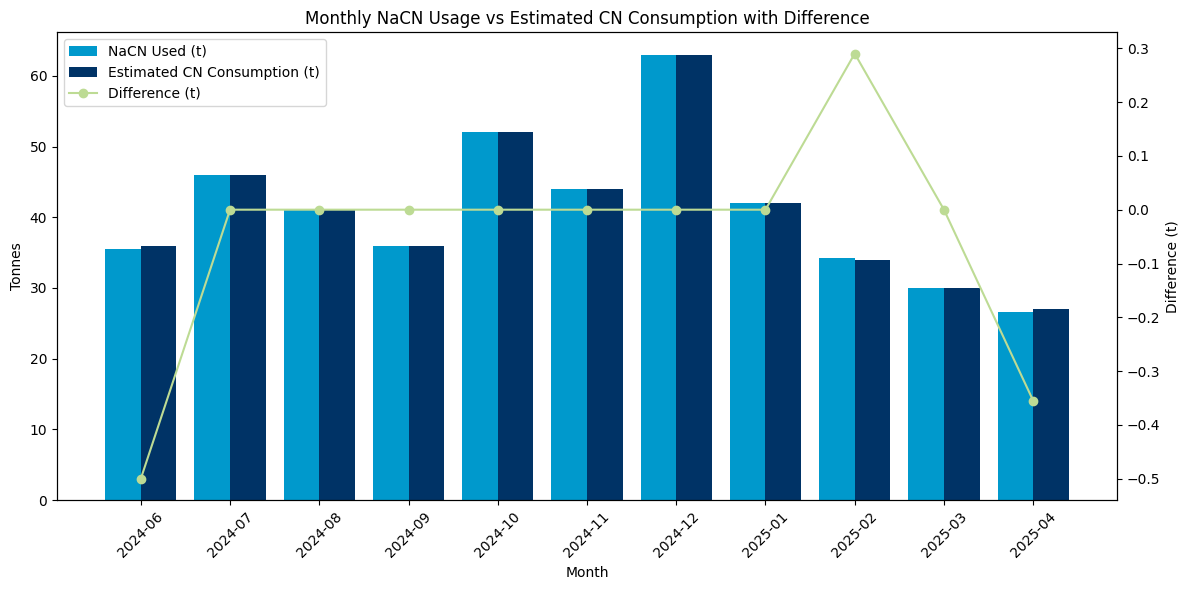

In [545]:
# Compare monthly Nacn_Used_T_Final with Estimated_CN_Kg converted to tonnes
def compare_monthly_cn_consumption(df: pd.DataFrame) -> pd.DataFrame:
	"""
	Compare monthly NaCN usage with estimated CN consumption.
	"""
	df["Month"] = df["Date"].dt.to_period("M")
	monthly_comparison = df.groupby("Month").agg({
		"Nacn_Used_T_Final": "sum",
		"Estimated_CN_Kg": "sum"
	}).reset_index()

	# Convert Estimated_CN_Kg to tonnes
	monthly_comparison["Cn_Consumed_Tonnes"] = round(monthly_comparison["Estimated_CN_Kg"] / 1000)
	# Convert 'Month' from Period to string or datetime
	monthly_comparison["Month_str"] = monthly_comparison["Month"].astype(str)

	return monthly_comparison

monthly_comparison = compare_monthly_cn_consumption(df_site_cleaned)

# Plot monthly comparison of NaCN usage vs estimated CN consumption
def plot_monthly_comparison_with_difference(monthly_comparison: pd.DataFrame):
	"""
	Plot monthly comparison of NaCN usage vs estimated CN consumption using bars,
	with difference plotted as a line on a secondary y-axis.
	"""
	# Prepare plotting column
	monthly_comparison["Month_str"] = monthly_comparison["Month"].astype(str)

	# Calculate difference
	monthly_comparison["Diff_Tonnes"] = (
		monthly_comparison["Nacn_Used_T_Final"] - monthly_comparison["Cn_Consumed_Tonnes"]
	)

	# Create plot
	fig, ax1 = plt.subplots(figsize=(12, 6))

	# Plot bars on primary y-axis
	bar_width = 0.4
	x = np.arange(len(monthly_comparison))

	ax1.bar(x - bar_width/2, monthly_comparison["Nacn_Used_T_Final"], 
			width=bar_width, label="NaCN Used (t)", color=def_colours[0])
	ax1.bar(x + bar_width/2, monthly_comparison["Cn_Consumed_Tonnes"], 
			width=bar_width, label="Estimated CN Consumption (t)", color=def_colours[1])
	ax1.set_ylabel("Tonnes")
	ax1.set_xlabel("Month")
	ax1.set_xticks(x)
	ax1.set_xticklabels(monthly_comparison["Month_str"], rotation=45)

	# Plot line on secondary y-axis
	ax2 = ax1.twinx()
	ax2.plot(x, monthly_comparison["Diff_Tonnes"], color=def_colours[2], marker='o', label="Difference (t)")
	ax2.set_ylabel("Difference (t)")

	# Add combined legend
	lines, labels = [], []
	for ax in [ax1, ax2]:
		line, label = ax.get_legend_handles_labels()
		lines += line
		labels += label
	ax1.legend(lines, labels, loc="upper left")

	plt.title("Monthly NaCN Usage vs Estimated CN Consumption with Difference")
	plt.tight_layout()
	plt.show()


plot_monthly_comparison_with_difference(monthly_comparison)

#### **🧩 Outcome:**
We now have a cleansed dataset with derived fields for:
* Clean CN usage (kg/day, kg/t),
* Reliable MTD and cumulative metrics,
* Blended estimates for simulation and visualisation.

#### **📌 So what?**
This cleaned dataset enables reliable feature engineering, model training, and operational diagnostics. It also supports traceability—each derived field is documented and can be validated.

**Cyanide Consumption Estimation – Cleaned and Derived Fields**
| Field                                     | Description                                                                     | Key Use Case                         |
| ----------------------------------------- | ------------------------------------------------------------------------------- | ------------------------------------ |
| `Cn_Adds_To_Tank_1` / `_Tank_2`           | Boolean flags for CN dosing in each leach tank (ppm > 50).                      | Diagnose dosing behaviour            |
| `CN_ppm`                                  | Daily average CN concentration across all tanks (using ffill/bfill imputation). | General CN strength indicator        |
| `All_CN_Cols_Missing`                     | Flags rows with no original CN data before imputation.                          | Confidence filtering                 |
| `O2_ppm`                                  | Avg dissolved oxygen across all tanks (zero/NaN → median).                      | Oxygen availability for kinetics     |
| `O2_row_fully_imputed`                    | Flags rows with all oxygen data imputed.                                        | Confidence filtering                 |
| `Nacn_Used_T` *(raw)*                     | Warehouse drawdown (t/day). May include batching, prep, or offsite transfer.    | ⚠ Not suitable for modelling         |
| `Nacn_Used_T_Cleaned`                     | Outliers (>6 t) masked.                                                         | Better for diagnostics               |
| `Nacn_Used_T_Cleaned_Imputed`             | Interpolated drawdown (t/day), gaps filled.                                     | ✅ Visualisation and inventory trends |
| `NaCN_Used_kg`                            | Cleaned/imputed drawdown in kilograms.                                          | Intermediate mass-based calculations |
| `Pulp_Density_Calc`                       | Estimated pulp density from % solids.                                           | Internal calc.                       |
| `Est_Cn_Consumption_Kg_Tank`              | Estimated CN input (kg) from leach tank ppm and feed volume.                    | ✅ Simulation and model input         |
| `Rolling_Cumulative_Nacn_Consumption_Kgt` | Cumulative CN usage (kg/t), smoothed over time.                                 | Long-term trendlines                 |
| `Mtd_Nacn_Consumption_Kgt_True`           | ✅ True month-to-date CN usage (kg/t).                                           | ✅ Reporting & dashboards             |
| `Mtd_Nacn_Consumption_Kgt_Filled`         | Smoothed fallback version of MTD.                                               | Internal use                         |
| `Daily_Nacn_Consumption_Kgt_Recalc`       | Recalculated CN usage per tonne (kg/t) from drawdown.                           | Diagnostics & fallback logic         |
| `Calc_Daily_Nacn_Consumption_Kgt`         | Derived daily kg/t from filled MTD deltas.                                      | Fallback only                        |
| `Daily_Nacn_Consumption_Kgt_Final`        | ✅ Final kg/t CN usage per day (recalc + fallback logic).                        | ✅ Modelling, visualisation, ML input |
| `Estimated_CN_Kg`                 | ✅ Final CN input (kg/day): 90% tank estimate + 10% warehouse.                   | ✅ Primary simulation input field     |


**Quick Reference Summary**
| Task                             | Best Field                               |
| -------------------------------- | ---------------------------------------- |
| **Model input (CN kg/day)**      | `Estimated_CN_Kg`                |
| **Model input (CN kg/t)**        | `Daily_Nacn_Consumption_Kgt_Final`       |
| **Monthly reports / dashboards** | `Mtd_Nacn_Consumption_Kgt_True`          |
| **Warehouse drawdown trends**    | `Nacn_Used_T_Cleaned_Imputed`            |
| **Operational dosing review**    | `Cn_Adds_To_Tank_1`, `Cn_Adds_To_Tank_2` |

## 📊 Define Helper Functions for Visualisations
#### **❓What we are doing:**
Defining reusable plotting functions for a variety of chart types that support visual model diagnostics, comparisons, and exploratory data analysis. These include:
* Line plots (single and dual-line),
* Grouped dual-line comparisons (e.g. monthly tank behaviour),
* Dual-axis bar-line charts (e.g. CN input vs. inventory),
* Grouped bar + line overlays (e.g. tonnes vs. grade),
* Actual vs. predicted scatter plots with 1:1 reference lines.

In [546]:
# Single-line plot
def plot_line(x, y, title="Line Plot", 
				   y_label="Value",
				   x_label="Services",
				   colour = None
				   ):
	if colour is None:
		colour = def_colours[0]
	plt.figure(figsize=(10, 6))
	plt.plot(x, y, label=y_label, marker='o', color=colour)
	plt.xticks(rotation=45)
	# plt.xlabel(x_title)
	# plt.ylabel(y_title)
	plt.title(title)
	plt.legend()
	plt.grid(True)
	plt.tight_layout()
	plt.show()

# Dual-line plot
def plot_line_dual(col1, col2, x,
				   col1_label="Predicted % Dissolved",
				   col2_label="Actual % Dissolved",
				   x_title="Tank", y_title="Gold Dissolution (%)",
				   title="Gold Dissolution Comparison"):
	
	colour1 = def_colours[0]
	colour2 = def_colours[1]

	plt.figure(figsize=(10, 6))
	plt.plot(x, col1, label=col1_label, marker='o', color=colour1)
	plt.plot(x, col2, label=col2_label, marker='x', color=colour2)
	plt.xticks(rotation=45)
	plt.xlabel(x_title)
	plt.ylabel(y_title)
	plt.title(title)
	plt.legend()
	plt.grid(True)
	plt.tight_layout()
	plt.show()


def plot_grouped_dual_line_comparison(
	df: pd.DataFrame,
	group_by: str,
	generate_lines_fn: Callable[[pd.DataFrame], Tuple[List[str], dict]],
	title_fn: Callable[[str], str] = lambda g: str(g),
	ylabel: str = "Value",
	xlabel: str = "X-Axis",
	legend_labels: List[str] = None,
	ncols: int = 3,
	figsize: Tuple[int, int] = (18, 4),
):
	"""
	Generic plotting function for grouped line comparisons.

	Parameters:
		df (pd.DataFrame): Source dataframe
		group_by (str): Column name to group by (e.g. 'Month')
		generate_lines_fn (Callable): Function that returns (x_labels, y_lines_dict)
		title_fn (Callable): Function to convert group key into subplot title
		ylabel (str): Label for y-axis
		xlabel (str): Label for x-axis
		legend_labels (List[str]): Custom legend labels (overrides dict keys if given)
		ncols (int): Number of columns in subplot grid
		figsize (Tuple): Base (width, height) per row of the subplot grid
	"""
	df[group_by] = pd.to_datetime(df["Date"]).dt.to_period("M")
	grouped = df.groupby(group_by)

	n_groups = len(grouped)
	nrows = int(np.ceil(n_groups / ncols))
	fig, axes = plt.subplots(nrows, ncols, figsize=(figsize[0], figsize[1] * nrows), sharey=True)
	axes = axes.flatten()

	for i, (group_key, group_df) in enumerate(grouped):
		x_labels, lines_dict = generate_lines_fn(group_df)

		ax = axes[i]
		for j, (label, y_values) in enumerate(lines_dict.items()):
			display_label = legend_labels[j] if legend_labels and j < len(legend_labels) else label
			colour = def_colours[j % len(def_colours)]
			ax.plot(x_labels, y_values, label=display_label, marker='o', color=colour)

		ax.set_title(title_fn(group_key))
		ax.set_xlabel(xlabel)
		ax.set_ylabel(ylabel)
		ax.set_xticks(range(len(x_labels)))
		ax.set_xticklabels(x_labels, rotation=45)
		ax.grid(True)
		ax.legend()

	for j in range(i + 1, len(axes)):
		fig.delaxes(axes[j])

	plt.tight_layout()
	plt.show()


def plot_dual_axis_bar_line(
	df,
	x_col,
	bar_col,
	line_col,
	bar_label="Bar Series",
	line_label="Line Series",
	x_label="Date",
	y1_label="Primary Axis",
	y2_label="Secondary Axis",
	title="Dual Axis Bar-Line Plot",
	bar_colour=None,
	bar_alpha=0.5,
	line_colour=None,
	line_alpha=1.0,
	date_format="%b\n%Y",
	figsize=(14, 6)
):
	"""
	Plots a dual-axis chart with a bar series and a line series.

	Parameters:
	- df (pd.DataFrame): DataFrame with the data
	- x_col (str): Name of the column to use as the x-axis
	- bar_col (str): Name of the column to plot as bars (left y-axis)
	- line_col (str): Name of the column to plot as line (right y-axis)
	- bar_label (str): Label for the bar series
	- line_label (str): Label for the line series
	- x_label (str): Label for the x-axis
	- y1_label (str): Label for the left y-axis
	- y2_label (str): Label for the right y-axis
	- title (str): Plot title
	- bar_colour (str): Colour for the bar series
	- bar_alpha (float): Transparency for the bar series
	- line_colour (str): Colour for the line series
	- line_alpha (float): Transparency for the line series
	- date_format (str): Format for x-axis dates
	- figsize (tuple): Size of the plot
	"""
	
	if bar_colour is None:
		bar_colour = def_colours[3]
	if line_colour is None:
		line_colour = def_colours[1]

# Create a working copy of a dataframe — safe for transformation below
	df = df.copy()
	df[x_col] = pd.to_datetime(df[x_col])

	fig, ax1 = plt.subplots(figsize=figsize)

	# Bar series (left axis)
	ax1.bar(df[x_col], df[bar_col], color=bar_colour, alpha=bar_alpha, label=bar_label)
	ax1.set_ylabel(y1_label, color=bar_colour)
	ax1.tick_params(axis='y', labelcolor=bar_colour)

	# Line series (right axis)
	ax2 = ax1.twinx()
	ax2.plot(df[x_col], df[line_col], color=line_colour, alpha=line_alpha,linewidth=2, label=line_label)
	ax2.set_ylabel(y2_label, color=line_colour)
	ax2.tick_params(axis='y', labelcolor=line_colour)

	# X-axis formatting
	ax1.set_xlabel(x_label)
	ax1.xaxis.set_major_locator(mdates.MonthLocator())
	ax1.xaxis.set_major_formatter(mdates.DateFormatter(date_format))

	# Title
	plt.title(title)

	# Combined legend
	lines_1, labels_1 = ax1.get_legend_handles_labels()
	lines_2, labels_2 = ax2.get_legend_handles_labels()
	ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

	plt.tight_layout()
	plt.show()



def plot_grouped_bar_with_secondary_lines(
	x_labels,
	bar_data,
	bar_labels,
	bar_colours=None,
	bar_width=0.25,
	bar_alpha=1.0,
	y1_label="Primary Y-axis",
	line_data=None,
	line_labels=None,
	line_colours=None,
	line_styles=None,
	y2_label="Secondary Y-axis",
	title="Grouped Bar and Line Chart",
	figsize=(14, 6),
	rotation=45,
):
	"""
	Plot a grouped bar chart with up to three bars per group and optional line plots on a secondary axis.

	Parameters:
		x_labels (List[str]): Labels for the x-axis (e.g., months)
		bar_data (List[pd.Series or List[float]]): List of datasets to plot as bars
		bar_labels (List[str]): Labels for the bars
		bar_colours (List[str], optional): Colours for the bars
		bar_width (float, optional): Width of each bar
		bar_alpha (float or List[float], optional): Transparency values for each bar (scalar or list)
		y1_label (str): Label for the primary Y-axis
		line_data (List[pd.Series or List[float]], optional): Line data to plot on secondary Y-axis
		line_labels (List[str], optional): Labels for line plots
		line_colours (List[str], optional): Colours for line plots
		line_styles (List[str], optional): Line styles for line plots
		y2_label (str): Label for the secondary Y-axis
		title (str): Chart title
		figsize (Tuple[int, int]): Figure size
		rotation (int): Rotation angle for x-tick labels
	"""
	x = list(range(len(x_labels)))
	fig, ax1 = plt.subplots(figsize=figsize)

	# Define default colours if not supplied
	if bar_colours is None:
		bar_colours = def_colours

	# If bar_alpha is scalar, convert to list with same value repeated
	if isinstance(bar_alpha, (float, int)):
		bar_alpha = [bar_alpha] * len(bar_data)

	# Plot grouped bars
	for i, (data, label) in enumerate(zip(bar_data, bar_labels)):
		offset = (i - 1) * bar_width  # shifts: -width, 0, +width for 3 bars
		ax1.bar(
			[xi + offset for xi in x],
			data,
			width=bar_width,
			label=label,
			alpha=bar_alpha[i],
			color=bar_colours[i % len(bar_colours)],
		)

	ax1.set_ylabel(y1_label)
	ax1.set_xticks(x)
	ax1.set_xticklabels(x_labels, rotation=rotation)
	ax1.set_title(title)

	# Add secondary lines if specified
	if line_data:
		ax2 = ax1.twinx()
		for i, (line, label) in enumerate(zip(line_data, line_labels)):
			colour = line_colours[i % len(line_colours)] if line_colours else def_colours[i % len(def_colours)]
			style = line_styles[i % len(line_styles)] if line_styles else "--"
			marker = "o" if i == 0 else "s"
			ax2.plot(
				x, line,
				linestyle=style,
				color=colour,
				marker=marker,
				label=label
			)
		ax2.set_ylabel(y2_label)
		ax2.axhline(0, color="grey", linewidth=1, linestyle="dotted")

		# Combine legends
		lines1, labels1 = ax1.get_legend_handles_labels()
		lines2, labels2 = ax2.get_legend_handles_labels()
		ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
	else:
		ax1.legend(loc="upper left")

	plt.tight_layout()
	plt.show()



def plot_actual_vs_predicted_scatter(
	df,
	actual_col,
	predicted_col,
	title="Actual vs Predicted",
	x_label="Actual",
	y_label="Predicted",
	point_colour=None,
	line_colour=def_colours[6],
	point_alpha=0.6,
	figsize=(10, 6)
):
	"""
	Plots an actual vs. predicted scatter plot with a 1:1 reference line.

	Parameters:
		df (pd.DataFrame): DataFrame containing actual and predicted columns
		actual_col (str): Column name for actual values
		predicted_col (str): Column name for predicted values
		title (str): Plot title
		x_label (str): Label for the x-axis
		y_label (str): Label for the y-axis
		point_colour (str): Colour for the scatter points; defaults to None (uses default colour)
		line_colour (str): Colour for the 1:1 reference line
		point_alpha (float): Alpha transparency for scatter points
		figsize (Tuple[int, int]): Size of the figure
	"""
	if point_colour is None:
		point_colour = def_colours[0]

	plt.figure(figsize=figsize)
	sns.scatterplot(x=actual_col, y=predicted_col, data=df, color=point_colour, alpha=point_alpha)

	# Draw 1:1 reference line
	max_val = max(df[actual_col].max(), df[predicted_col].max())
	plt.plot([0, max_val], [0, max_val], linestyle="--", color=line_colour)

	# Axis labels and title
	plt.xlabel(x_label)
	plt.ylabel(y_label)
	plt.title(title)

	plt.tight_layout()
	plt.show()

---

# **Section 1: Develop a Gold Dissolution Model**

Develop a model that simulates gold dissolution behaviour in the leaching circuit, following the methodology developed by Lima & de Andrade Hodouin (2005) while drawing on process and chemical parameters derived earlier.

Accurate simulation of gold dissolution is key to optimising cyanide use, improving recovery, and supporting operational decisions on grind size, oxygenation, and CN dosing strategy.

---

## 🔀 Step 1: Split the data into training and testing datasets

#### **❓What we are doing:**
Split the cleansed dataset into training and testing subsets to assess how well the model generalises to unseen data.

#### **❗Why this matters:**
A clean train/test split ensures that model performance metrics are meaningful and not overfitting to known values.


In [547]:
essential_cols = ['Leach_Feed_Grade_Au_Gt_Day', 'Daily_Milledtreated_Tons']
df_grade_milled = df_site_cleaned.dropna(subset=essential_cols)

# Use chronological split for time-series consistency
df_train, df_test = train_test_split(df_grade_milled, test_size=0.2, shuffle=False)

### **⏳ Next:**
Define our features and target variables for model training in the following steps.

## 🧪 Step 2: Define Kinetic Models
Define two gold dissolution models for simulation:
1. **`lima_hodouin_dissolution`:** Implements the rate equation from Lima & Hodouin (2005), with dependency on CN, O₂, and residual gold.
2. **`hybrid_dissolution`:** A pragmatic two-stage exponential model with fast and slow components based on particle size.


In [548]:
# Lima & Hodouin kinetic rate model
def lima_hodouin_dissolution(Au_s, Au_sl, CN, O2, d, k1=1.13e-3, k2=4.37e-11,
							  a=2.13, b=0.961, c=0.228, d_exp=2.93,
							  max_rate=0.25):
	"""Return rate in mg/kg/h"""
	k = k1 - k2 * d**d_exp
	if k <= 0 or CN <= 0 or O2 <= 0:
		return 0
	delta = max(Au_s - Au_sl, 0)
	rate = k * delta**a * CN**b * O2**c
	return np.clip(rate, 0, max_rate)


# Hybrid two-stage exponential model
def hybrid_dissolution(d, t, au0, threshold=50, A=2.98e2, B=2.21,
					   f_fast=0.6, fast_mult=3.0, slow_mult=0.3):
	k = A * d**(-B)
	if d <= threshold:
		k_fast = k * fast_mult
		k_slow = k * slow_mult
		return f_fast * au0 * np.exp(-k_fast * t) + (1 - f_fast) * au0 * np.exp(-k_slow * t)
	else:
		return au0 * np.exp(-k * t)

📌 Both models return time-dependent gold dissolution values in mg/kg or %. The L&H model is rate-based; the hybrid model uses time-based exponential decay.

📌 These models will be used to simulate tank-by-tank dissolution and compare different recovery predictions.

## Step 3: Simulation and Model Evaluation
Begin simulation of tank-wise gold dissolution using both kinetic models.
Simulate one day’s worth of leaching by propagating gold dissolution across 11 tanks, applying residence time and process values from the dataset.

Use this simulation to validate logic, parameter usage, and rate behaviour across both models.

### 🔧 3.1 Run Simulation
Extract a representative row from `df_train`.

**Define key inputs:**
feed grade (mg/kg), CN concentration (ppm), O₂ concentration (ppm), and particle size (µm).

Simulate gold dissolution across 11 tanks using both the hybrid and Lima & Hodouin models.

In [549]:
# Simulate tank-by-tank dissolution for a single day (index 0)
row = df_train.iloc[1]
feed_grade_mgkg = row["Leach_Feed_Grade_Au_Gt_Day"]
locked_gold_floor = feed_grade_mgkg * locked_gold_threshold

percent_solids = row["Percentsolids"]
CN = row["CN_ppm"]
O2 = row["O2_ppm"]

tanks = [f"Tank {i+1}" for i in range(11)]
residence_per_tank = total_residence_time / len(tanks)

# Hybrid model
au_remaining = feed_grade_mgkg * liberation_fraction
hybrid_pct = []
for _ in tanks:
	au_remaining = hybrid_dissolution(d, residence_per_tank, au_remaining)
	hybrid_pct.append((feed_grade_mgkg - au_remaining) / feed_grade_mgkg * 100)

# L&H model
au_remaining_lh = feed_grade_mgkg * liberation_fraction
lh_pct = []

print(f"Feed grade: {au_remaining_lh:.2f} mg/kg, CN: {CN:.1f}, O2: {O2:.1f}, d: {d:.1f}")
print(f"Locked gold floor: {locked_gold_floor:.2f} mg/kg, which is {locked_gold_threshold * 100:.1f}% of feed grade")
print("Tank | Rate (g/kg/h) | Delta (mg/kg) | Remaining_Au_lh | Dissolved_%")

for idx, _ in enumerate(tanks):
	rate = lima_hodouin_dissolution(au_remaining_lh, locked_gold_floor, CN, O2, d)
	delta = min(rate * residence_per_tank, au_remaining_lh)
	au_remaining_lh = max(au_remaining_lh - delta, locked_gold_floor)
	
	pct = (feed_grade_mgkg * liberation_fraction - au_remaining_lh) / (feed_grade_mgkg * liberation_fraction) * 100
	lh_pct.append(pct)
	
	print(f"{idx+1:>4} | {rate:.9f} | {delta:.2f} | {au_remaining_lh:.2f} | {pct:.2f}")


Feed grade: 2.43 mg/kg, CN: 422.7, O2: 9.7, d: 20.0
Locked gold floor: 0.05 mg/kg, which is 2.0% of feed grade
Tank | Rate (g/kg/h) | Delta (mg/kg) | Remaining_Au_lh | Dissolved_%
   1 | 0.250000000 | 0.68 | 1.75 | 28.05
   2 | 0.250000000 | 0.68 | 1.07 | 56.11
   3 | 0.250000000 | 0.68 | 0.38 | 84.16
   4 | 0.061776969 | 0.17 | 0.22 | 91.09
   5 | 0.013968623 | 0.04 | 0.18 | 92.66
   6 | 0.008042821 | 0.02 | 0.16 | 93.56
   7 | 0.005403289 | 0.01 | 0.14 | 94.17
   8 | 0.003938711 | 0.01 | 0.13 | 94.61
   9 | 0.003024323 | 0.01 | 0.12 | 94.95
  10 | 0.002408454 | 0.01 | 0.12 | 95.22
  11 | 0.001970829 | 0.01 | 0.11 | 95.44


#### **🧩 Outcome:**
Simulation completed successfully. The L&H model shows diminishing rates as Au is consumed. A hybrid model could potentially provide a smoother exponential decay.

#### **📌 So what?**
Use these results to validate model behaviour. Look for saturation effects, excessive early leaching, or unrealistic final recoveries.

### 📈 3.2 Plot Hybrid vs L&H vs Actual for Single Day
Simulate and plot gold dissolution for a single day using both kinetic models.
Display predicted recovery vs actual observed undissolved Au in tanks for that day.
This supports visual validation of the models on a micro (per-day) scale.

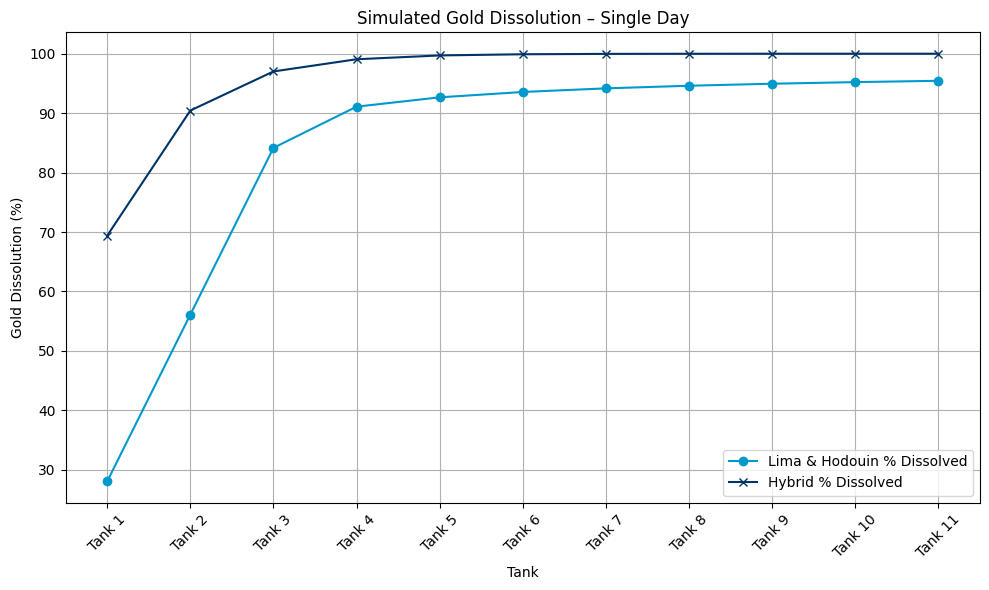

In [550]:
plot_line_dual(lh_pct, hybrid_pct, tanks,
				col1_label="Lima & Hodouin % Dissolved",
				col2_label="Hybrid % Dissolved",
				x_title="Tank", y_title="Gold Dissolution (%)",
				title="Simulated Gold Dissolution – Single Day")

#### **📌 So what?**
The aim is to confirm that the predicted dissolution trends align with measured tank-by-tank values for a specific operating day. From the plot above, the shape of both models is similar, with the Hybrid model starting slower, rapidly accelerating over tanks 2-3 then decaying rapidly. 

The locked gold setting defines the fine recovery in the curve. BAsed in gold dissolution kinetics, potentially tune the parameters in the Hybrid model to accelerate dissolution in the first and second tanks (expect more dissolution should tank place in Pre-leaching tanks)

### 📊 3.3 Plot Monthly Comparison Panels

#### **❓What we are doing:**
Group the training dataset by month and simulate gold dissolution across tanks using both kinetic models (Hybrid and Lima & Hodouin).
For each month:
* Calculate mean CN, O₂, feed grade, and milled tonnage.
* Estimate undissolved gold from tank data and convert it to % dissolved.
* Plot predicted vs actual tank-wise dissolution profiles.

#### **❗Why this matters:**
This step enables visual comparison between predicted recovery (from kinetic models) and actual gold remaining in leach tanks. It helps validate both the model structure and parameter realism.

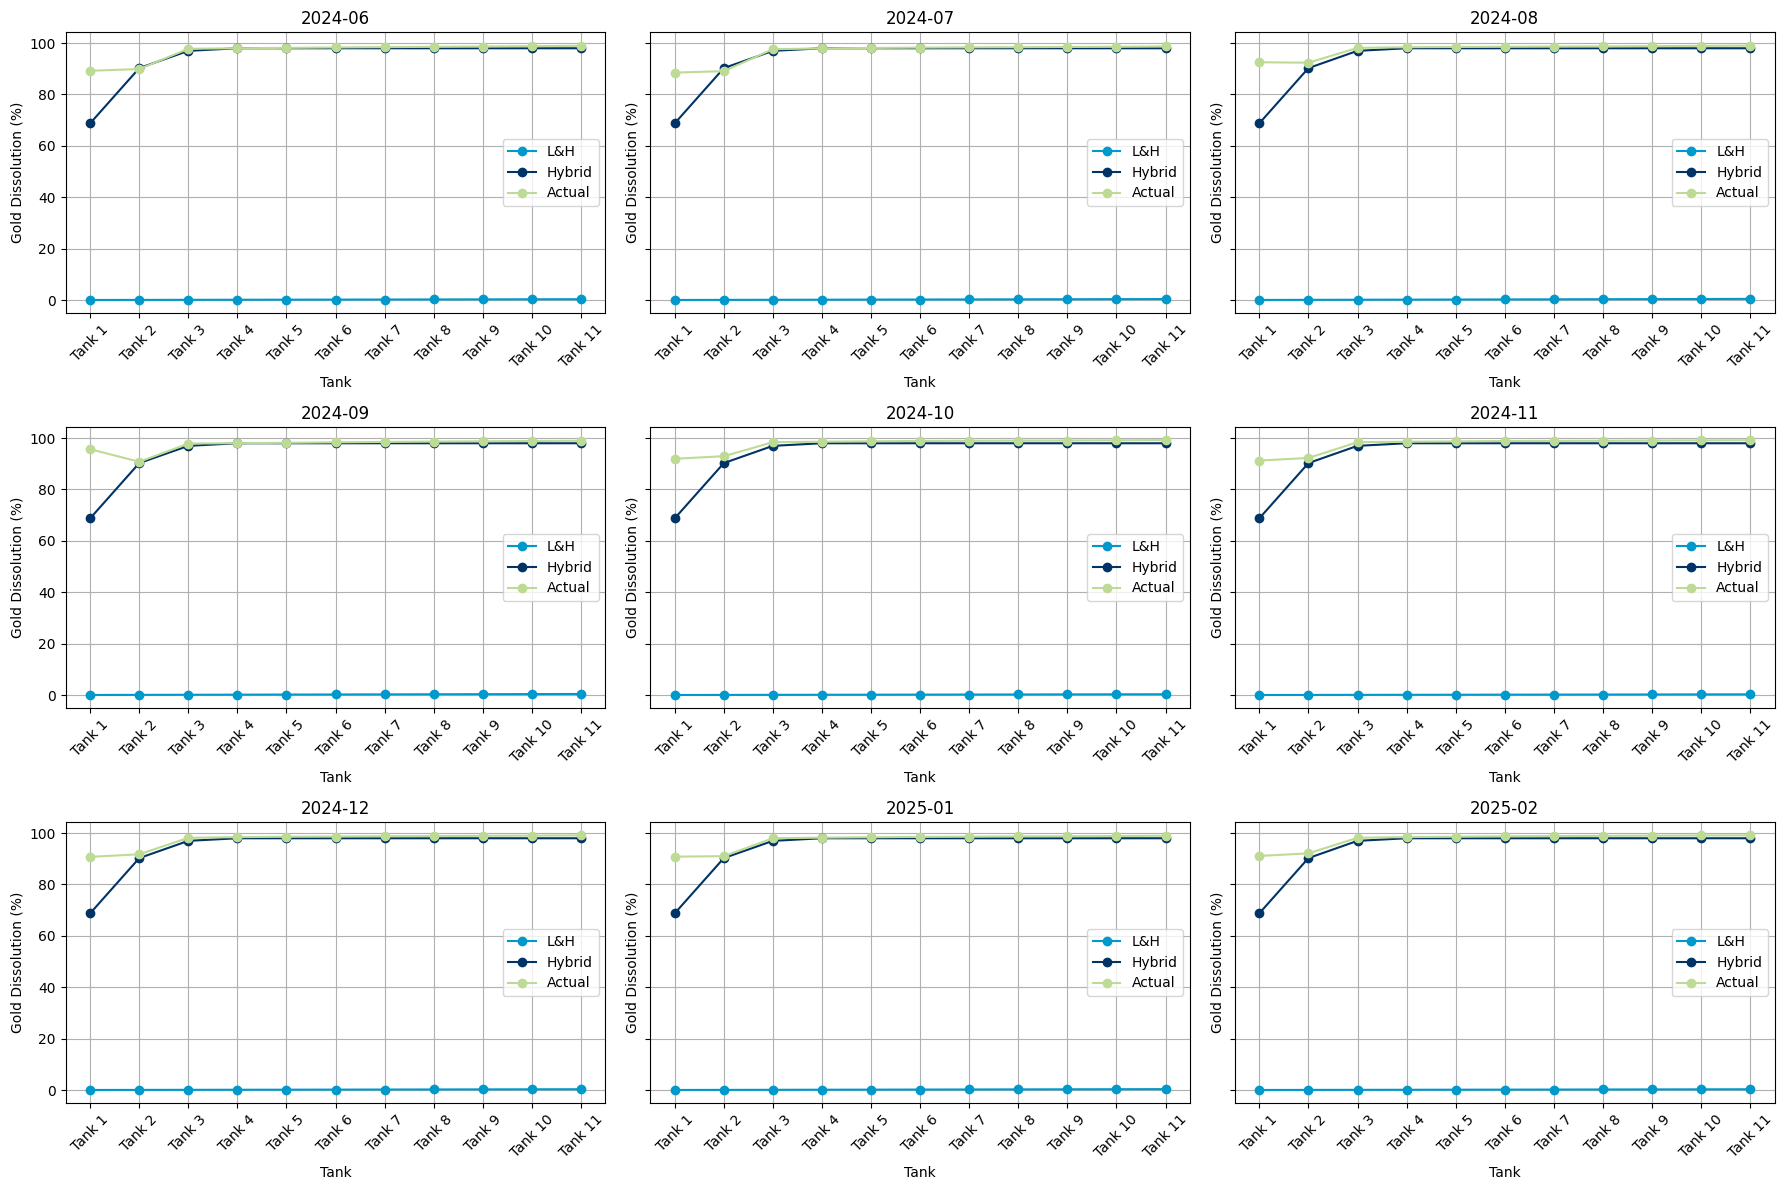

In [551]:
def plot_monthly_dissolution_comparison(df, group_by="Month"):

	# Assign month
	df[group_by] = pd.to_datetime(df["Date"]).dt.to_period("M")
	grouped = df.groupby(group_by)

	def run_models(adjusted_feed, locked_gold_floor, avg_feed_grade, CN, O2, d, n_tanks=11):
		t = total_residence_time / n_tanks
		tanks = [f"Tank {i+1}" for i in range(n_tanks)]
		
		# Lima & Hodouin
		au_lh = adjusted_feed
		pred_lh = []
		for _ in tanks:
			rate = lima_hodouin_dissolution(au_lh, locked_gold_floor, CN, O2, d)
			delta = min(rate * t, au_lh)
			au_lh = max(au_lh - delta, locked_gold_floor)
			pct = (adjusted_feed - au_lh) / avg_feed_grade * 100
			pred_lh.append(pct)

		# Hybrid
		au_hybrid = adjusted_feed
		pred_hybrid = []
		for i, _ in enumerate(tanks):
			if i in [0, 1]:  # Pre-leach tanks
				t_effective = t * 1  # or even 2.0, depending on residence logic
			else:
				t_effective = t
			au_hybrid = max(hybrid_dissolution(d, t_effective, au_hybrid), locked_gold_floor)
			pct = (adjusted_feed - au_hybrid) / adjusted_feed * 100
			pred_hybrid.append(pct)

		return tanks, pred_lh, pred_hybrid

	n_months = len(grouped)
	ncols = 3
	nrows = int(np.ceil(n_months / ncols))
	fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), sharey=True)
	axes = axes.flatten()

	for i, (month, group) in enumerate(grouped):
		tank_cols = [col for col in group.columns if "Undissolved_Gold" in col and "Grams_Per_Day" in col]
		grams_per_day = group[tank_cols].mean().values
		n_tanks = len(grams_per_day)

		avg_feed_grade = group["Leach_Feed_Grade_Au_Gt_Day"].mean() * 1000
		avg_milled = group["Daily_Milledtreated_Tons"].mean()
		total_gold_fed = (avg_feed_grade / 1e6) * avg_milled * 1e3
		adjusted_feed = avg_feed_grade * liberation_fraction

		locked_gold_floor = avg_feed_grade * locked_gold_threshold
		percent_solids = group["Percentsolids"].mean()
		CN = group["CN_ppm"].mean()
		O2 = group["O2_ppm"].mean()

		au_undissolved_mgkg = (grams_per_day / total_gold_fed) * avg_feed_grade
		actual_pct = (adjusted_feed - au_undissolved_mgkg) / adjusted_feed * 100

		tanks, pred_lh, pred_hybrid = run_models(adjusted_feed,
										   locked_gold_floor,
										   avg_feed_grade,
										   CN, O2, d, n_tanks)

		ax = axes[i]
		# ax.plot(tanks, pred_lh, label="L&H", marker='o')
		ax.plot(tanks, pred_hybrid, label="Hybrid", marker='x')
		ax.plot(tanks, actual_pct, label="Actual", marker='s')
		ax.set_title(str(month))
		ax.set_xlabel("Tank")
		ax.set_ylabel("Gold Dissolution (%)")
		ax.set_xticks(range(len(tanks)))
		ax.set_xticklabels(tanks, rotation=45)
		ax.grid(True)
		ax.legend()

	for j in range(i + 1, len(axes)):
		fig.delaxes(axes[j])

	plt.tight_layout()
	plt.show()

def generate_dissolution_lines(group):
	tank_cols = [col for col in group.columns if "Undissolved_Gold" in col and "Grams_Per_Day" in col]
	grams_per_day = group[tank_cols].mean().values
	n_tanks = len(grams_per_day)

	avg_feed_grade = group["Leach_Feed_Grade_Au_Gt_Day"].mean() * 1000  # g/t → mg/kg
	avg_milled = group["Daily_Milledtreated_Tons"].mean()
	total_gold_fed = (avg_feed_grade / 1e6) * avg_milled * 1e3  # t × mg/kg → grams
	adjusted_feed = avg_feed_grade * liberation_fraction
	locked_gold_floor = avg_feed_grade * locked_gold_threshold
	percent_solids = group["Percentsolids"].mean()
	CN = group["CN_ppm"].mean()
	O2 = group["O2_ppm"].mean()

	# Convert grams per day → mg/kg
	au_undissolved_mgkg = (grams_per_day / total_gold_fed) * avg_feed_grade
	actual_pct = (adjusted_feed - au_undissolved_mgkg) / adjusted_feed * 100

	def run_models(adjusted_feed, locked_gold_floor, avg_feed_grade, CN, O2, d, n_tanks=11):
		t = total_residence_time / n_tanks
		tanks = [f"Tank {i+1}" for i in range(n_tanks)]

		# L&H model
		au_lh = adjusted_feed
		pred_lh = []
		for _ in tanks:
			rate = lima_hodouin_dissolution(au_lh, locked_gold_floor, CN, O2, d)
			delta = min(rate * t, au_lh)
			au_lh = max(au_lh - delta, locked_gold_floor)
			pct = (adjusted_feed - au_lh) / avg_feed_grade * 100
			pred_lh.append(pct)

		# Hybrid model
		au_hybrid = adjusted_feed
		pred_hybrid = []
		for i, _ in enumerate(tanks):
			t_effective = t if i >= 2 else t * 1  # pre-leach can be doubled if desired
			au_hybrid = max(hybrid_dissolution(d, t_effective, au_hybrid), locked_gold_floor)
			pct = (adjusted_feed - au_hybrid) / adjusted_feed * 100
			pred_hybrid.append(pct)

		return tanks, pred_lh, pred_hybrid

	tanks, pred_lh, pred_hybrid = run_models(
		adjusted_feed,
		locked_gold_floor,
		avg_feed_grade,
		CN, O2, d,
		n_tanks=n_tanks
	)

	return tanks, {
		"L&H": pred_lh,
		"Hybrid": pred_hybrid,
		"Actual": actual_pct
	}


plot_grouped_dual_line_comparison(
	df=df_train,
	group_by="Month",
	generate_lines_fn=generate_dissolution_lines,
	ylabel="Gold Dissolution (%)",
	xlabel="Tank",
)


#### **🧩 Outcome:**
Output is a grid of plots showing actual vs predicted dissolution by tank, for each calendar month.
Each subplot allows visual validation of whether models accurately reflect the observed tank trends.

#### **📌 Use these results to:**
* Refine model assumptions (e.g. residence time, liberation fraction).
* Investigate months where predictions diverge from actual performance.
* Select which model (Hybrid or L&H) aligns better with plant data.

---

# Section 2: Develop a Cyanide Consumption Model

Predict cyanide consumption using plant process inputs (e.g. grade, throughput, oxygen, tailings CN).
This section will build, validate, and tune a model to explain daily NaCN usage.

---

In [552]:
# Create a working copy of a dataframe — safe for transformation below
df_cn = df_site_cleaned.copy()

## Step 1: Plot Daily Estimated CN Consumption vs Milled & Treated tonnes

Visualise how estimated cyanide consumption per day relates to daily milled and treated tonnage.
The purpose is to verify whether consumption scales logically with ore throughput and whether any trends or anomalies stand out.

#### **❗Why this matters:**
Cyanide consumption is expected to correlate with treated tonnes. Deviations may point to dosing inefficiencies or other operational issues.

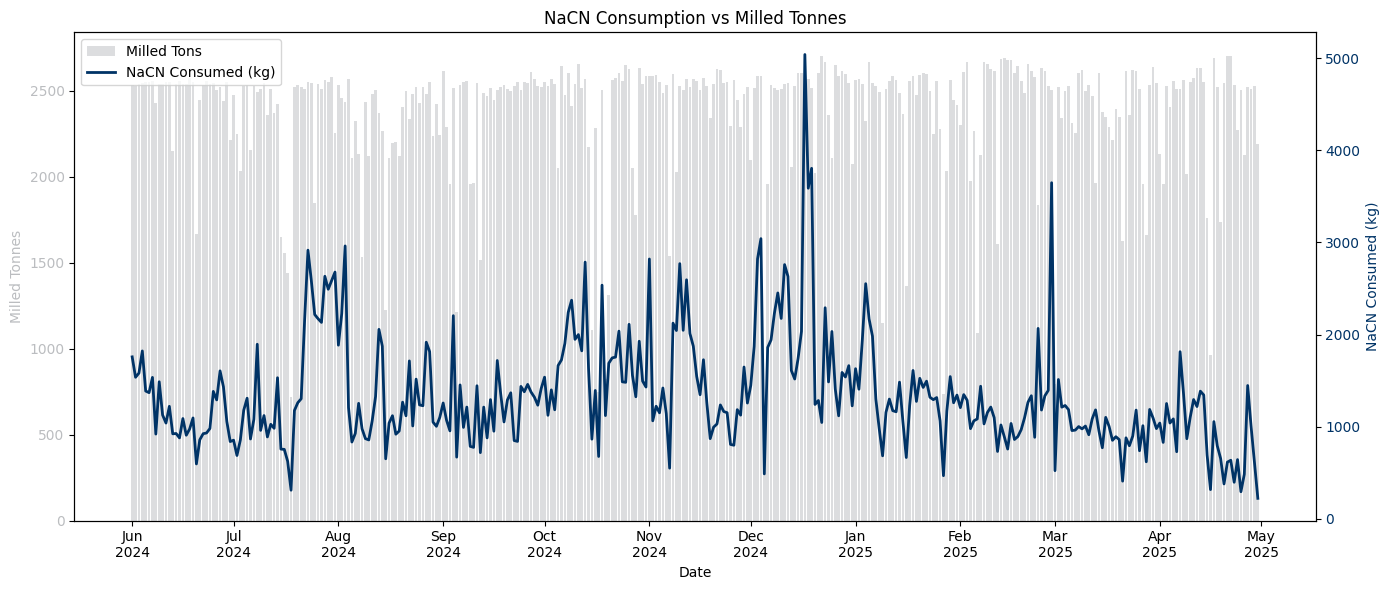

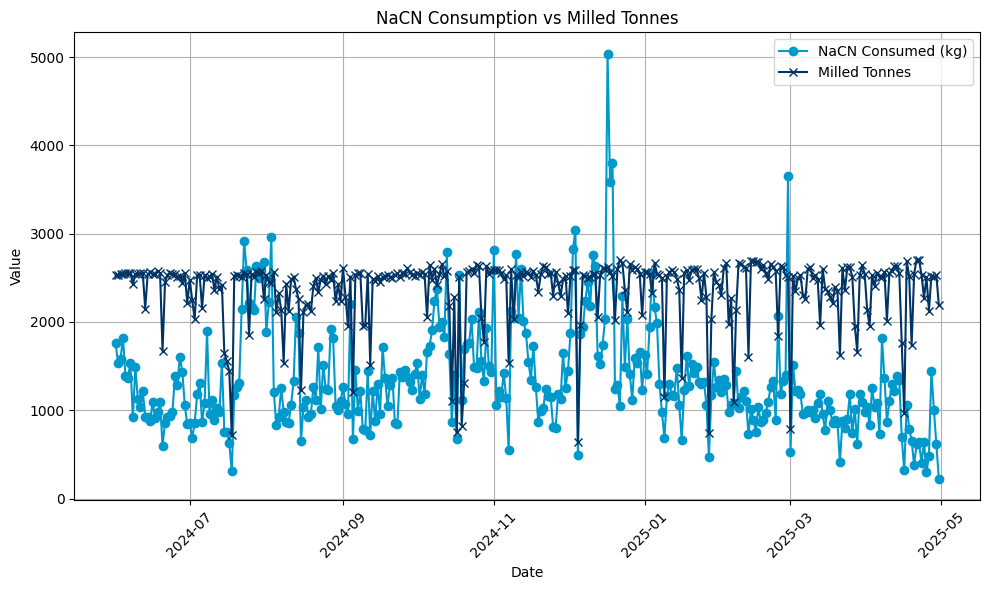

In [553]:
plot_dual_axis_bar_line(
	df=df_cn,
	x_col="Date",
	bar_col="Daily_Milledtreated_Tons",
	line_col="Estimated_CN_Kg",
	bar_label="Milled Tons",
	line_label="NaCN Consumed (kg)",
	x_label="Date",	
	y1_label="Milled Tonnes",
	y2_label="NaCN Consumed (kg)",
	title="NaCN Consumption vs Milled Tonnes"
)

# Plot the same plot on a dual line plot
plot_line_dual(
	df_cn["Estimated_CN_Kg"],
	df_cn["Daily_Milledtreated_Tons"],
	df_cn["Date"],
	col1_label="NaCN Consumed (kg)",
	col2_label="Milled Tonnes",
	x_title="Date",
	y_title="Value",
	title="NaCN Consumption vs Milled Tonnes"
)


A clear comparison is provided between tonnes treated (primary axis) and estimated NaCN used (secondary axis). This helps confirm that modelled CN usage broadly follows operational load.

#### **📌 Use this plot to:**
* Identify potential over- or under-dosing days,
* Flag unexpected consumption spikes or dips,
* Support communication with operations about dosing consistency.

## Derive average monthly dosage (ppm) using recorded daily inventory withdrawls as basis of calculation
Identify variability in NaCN usage across the dataset and prepare to derive a more consistent “actual” daily usage metric.
Use daily NaCN inventory withdrawal data (in tonnes) as the source of truth.
Cap extreme values using a defined ceiling, convert to kg, and use this to back-calculate implied cyanide dosage in ppm.

#### **❗Why this matters:**
Raw NaCN usage data includes anomalies and unreliable entries. Cleansing and standardisation are needed before training any robust models.

In [554]:
df_cn.columns.to_list()

['Date',
 'Leach_Feed_Throughput_M3Hr',
 'Leach_Feed_Throughput_M3Day',
 'Percentsolids',
 'Leach_Feed_Grade_Au_Gt_Ds',
 'Leach_Feed_Grade_Au_Gt_Ns',
 'Leach_Feed_Grade_Au_Gt_Day',
 'Leach_Feed_Grade_Ag_Gt_Ds',
 'Leach_Feed_Grade_Ag_Gt_Ns',
 'Leach_Feed_Grade_Ag_Gt_Day',
 'Cn_Added_Free_Cn_Ppm_Leach_Tank_1',
 'Cn_Added_Free_Cn_Ppm_Leach_Tank_2',
 'Daily_Nacn_Consumption_Kgt',
 'Mtd_Nacn_Consumption_Kgt',
 'Nacn_Used_T',
 'Cil_Feed_Total_Au_Grams',
 'Cn_Conc_Tailing_Ppm',
 'Total_Au_Tailing_Grams',
 'Leach_Feed_150Μm_Day',
 'Leach_Feed_75Μm_Day',
 'Leach_Feed_75Μm_Day',
 'Cyanide_Profile_Ppm_Leach_Tank_1',
 'Cyanide_Profile_Ppm_Leach_Tank_2',
 'Cyanide_Profile_Ppm_Cil_Tank_01',
 'Cyanide_Profile_Ppm_Cil_Tank_02',
 'Cyanide_Profile_Ppm_Cil_Tank_03',
 'Cyanide_Profile_Ppm_Cil_Tank_04',
 'Cyanide_Profile_Ppm_Cil_Tank_05',
 'Cyanide_Profile_Ppm_Cil_Tank_06',
 'Cyanide_Profile_Ppm_Cil_Tank_07',
 'Cyanide_Profile_Ppm_Cil_Tank_08',
 'Cyanide_Profile_Ppm_Cil_Tank_09',
 'Dissolved_Oxygen_Profile

In [555]:
# % solids to fractional solids
df_cn["Solids_Fraction"] = df_cn["Percentsolids"] / 100

# Wet mass of slurry (kg)
df_cn["Slurry_Mass_Kg"] = df_cn["Daily_Milledtreated_Tons"] * 1000 / df_cn["Solids_Fraction"]

# Calculate CN kg in tailings
df_cn["NaCN_Tailing_Kg"] = df_cn["Cn_Conc_Tailing_Ppm"] * df_cn["Slurry_Mass_Kg"] / 1e6

df_cn["NaCN_Tailing_pct"] = (
	df_cn["NaCN_Tailing_Kg"] /
	df_cn["Estimated_CN_Kg"]
) * 100

# Sum Leach_Feed_Throughput_M3Day by month
monthly_feed = df_cn.groupby(df_cn["Date"].dt.to_period("M"))["Daily_Milledtreated_Tons"].sum().reset_index()
monthly_used_cn = df_cn.groupby(df_cn["Date"].dt.to_period("M"))["Estimated_CN_Kg"].sum().reset_index()
monthly_cn = df_cn.groupby(df_cn["Date"].dt.to_period("M"))["Estimated_CN_Kg"].sum().reset_index()
# Calculate monthly CN in tailings
monthly_tailing_cn = df_cn.groupby(df_cn["Date"].dt.to_period("M"))["NaCN_Tailing_Kg"].sum().reset_index()

# Display the monthly throughput, CN consumption and tailings in a table
monthly_summary = pd.merge(round(monthly_feed), round(monthly_cn), on="Date")
monthly_summary = pd.merge(monthly_summary, round(monthly_used_cn), on="Date")
monthly_summary = pd.merge(monthly_summary, round(monthly_tailing_cn), on="Date")
# Add a tailing percentage column
monthly_summary.columns = ["Month", "Total_Feed_Tonnes", "Total_CN_Used_Kg", "Total_Est_CN_Consumed_Kg", "Total_CN_Tailing_kg"]
monthly_summary["Tailing_CN_pct"] = round((
	monthly_summary["Total_CN_Tailing_kg"] /
	monthly_summary["Total_Est_CN_Consumed_Kg"]
) * 100, 1)
print(monthly_summary)

      Month  Total_Feed_Tonnes  Total_CN_Used_Kg  Total_Est_CN_Consumed_Kg  \
0   2024-06            74418.0           35500.0                   35500.0   
1   2024-07            71123.0           46000.0                   46000.0   
2   2024-08            71250.0           41000.0                   41000.0   
3   2024-09            71614.0           36000.0                   36000.0   
4   2024-10            70785.0           52000.0                   52000.0   
5   2024-11            74213.0           44000.0                   44000.0   
6   2024-12            74593.0           63000.0                   63000.0   
7   2025-01            73030.0           42000.0                   42000.0   
8   2025-02            68243.0           34290.0                   34290.0   
9   2025-03            72216.0           30000.0                   30000.0   
10  2025-04            70944.0           26645.0                   26645.0   

    Total_CN_Tailing_kg  Tailing_CN_pct  
0               32979

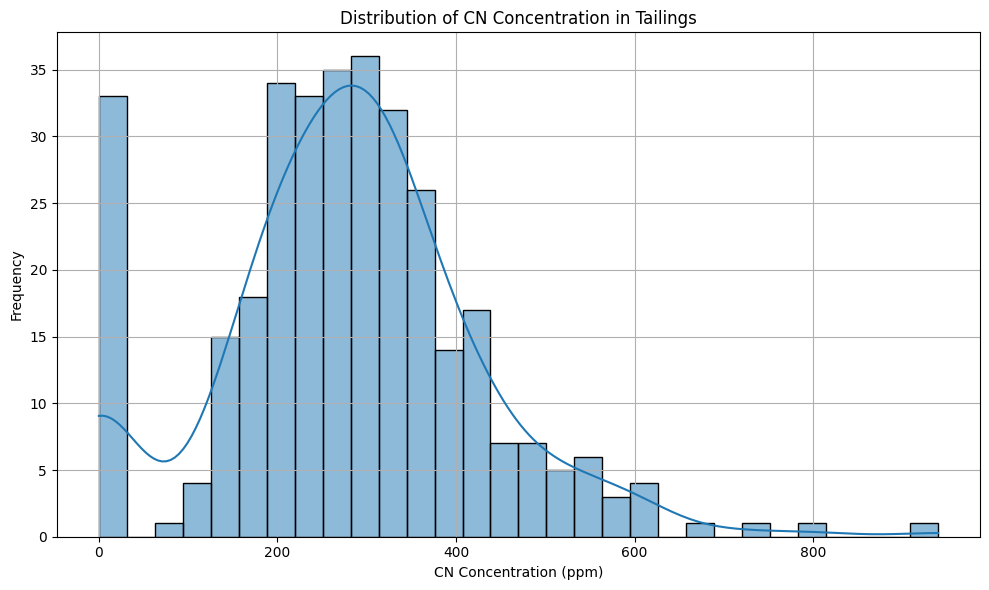

In [556]:
# Plot a distribution of the CN ppm in the tailings
plt.figure(figsize=(10, 6))
sns.histplot(df_cn["Cn_Conc_Tailing_Ppm"], bins=30, kde=True)
plt.title("Distribution of CN Concentration in Tailings")
plt.xlabel("CN Concentration (ppm)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

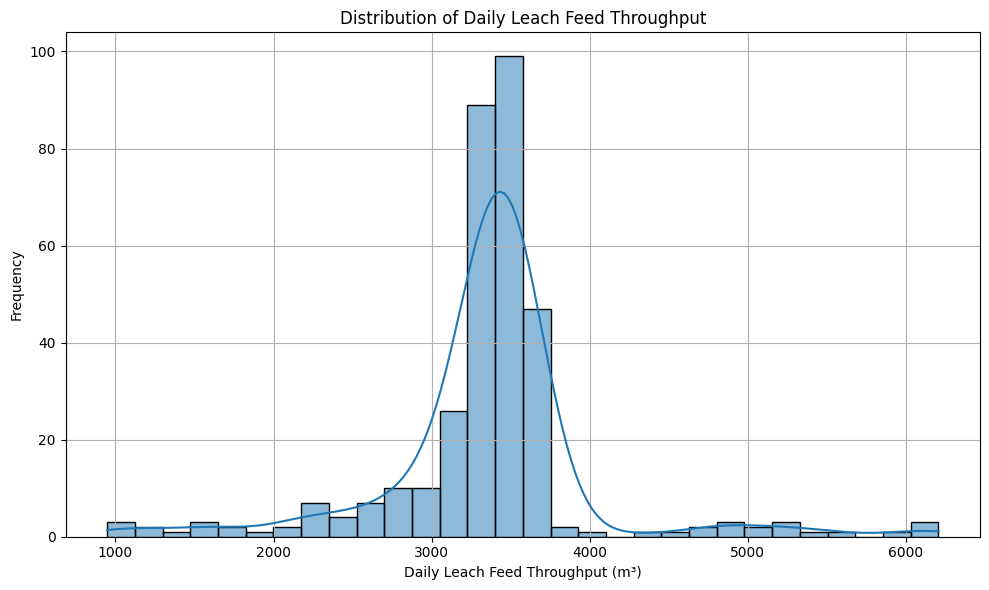

In [557]:
# Plot a distribution of the daily throughput
plt.figure(figsize=(10, 6))
sns.histplot(df_cn["Leach_Feed_Throughput_M3Day"], bins=30, kde=True)
plt.title("Distribution of Daily Leach Feed Throughput")
plt.xlabel("Daily Leach Feed Throughput (m³)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

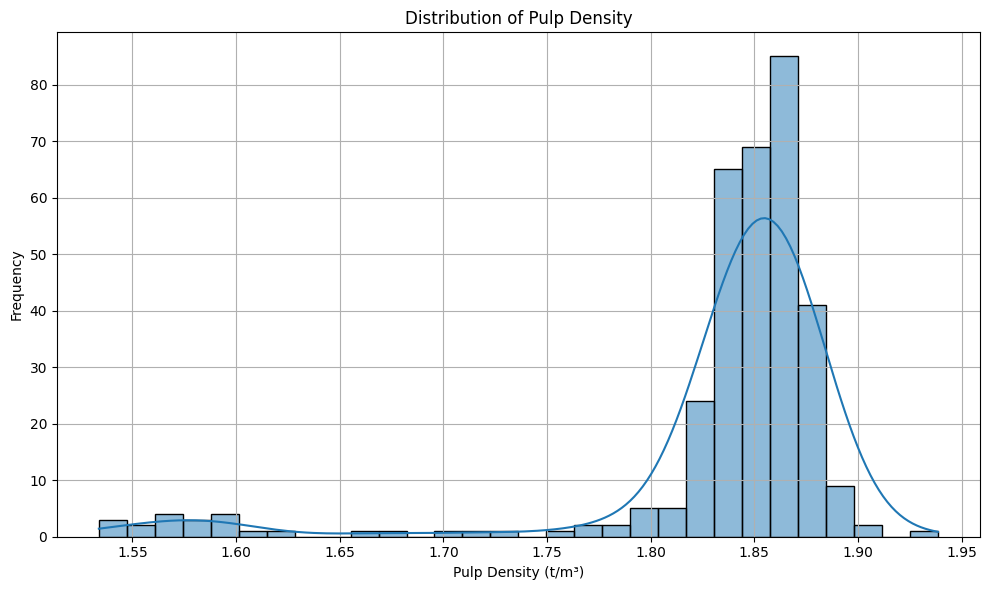

In [558]:
# Plot a distribution of the Pulp_Density_Calc
plt.figure(figsize=(10, 6))
sns.histplot(df_cn["Pulp_Density_Calc"], bins=30, kde=True)
plt.title("Distribution of Pulp Density")
plt.xlabel("Pulp Density (t/m³)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

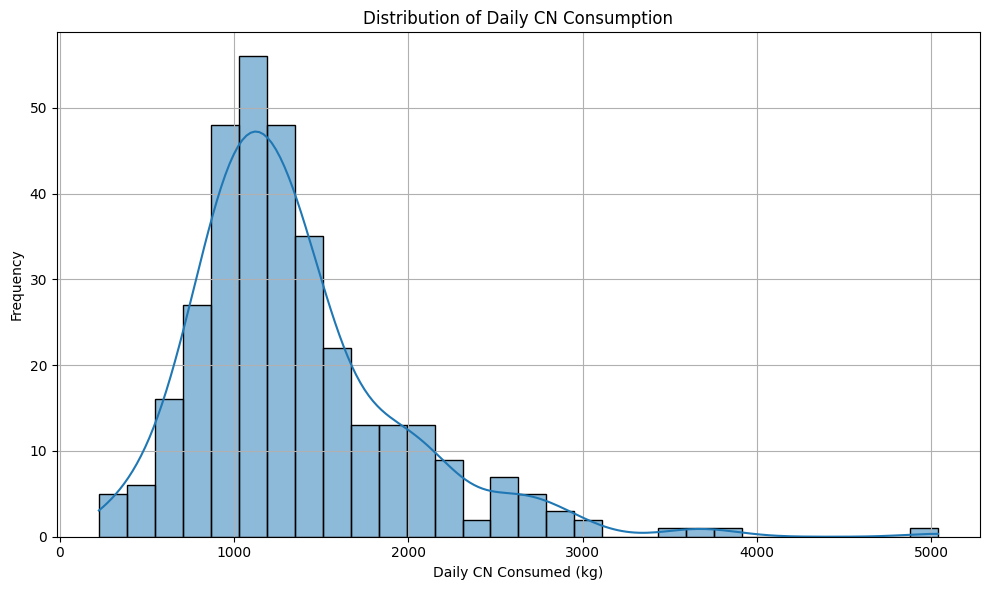

In [559]:
# Plot a distribution of the Estimated_CN_Kg
plt.figure(figsize=(10, 6))
sns.histplot(df_cn["Estimated_CN_Kg"], bins=30, kde=True)
plt.title("Distribution of Daily CN Consumption")
plt.xlabel("Daily CN Consumed (kg)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

In [560]:
# Monthly average estimated dosage (ppm)
monthly_avg_cn_ppm = df_cn.groupby("Month")["Estimated_CN_ppm"].mean()

# Monthly actual usage (t)
monthly_actual_cn_tonnes = df_cn.groupby("Month")["Estimated_CN_Kg"].sum() / 1000

# Create summary table
df_dosage_summary = pd.DataFrame({
	"Avg_Estimated_CN_ppm": round(monthly_avg_cn_ppm),
	"NaCN_Used_t": monthly_actual_cn_tonnes
})

df_dosage_summary

,Avg_Estimated_CN_ppm,NaCN_Used_t
Month,,
2024-06,239.0,35.500
2024-07,303.0,46.000
2024-08,225.0,41.000
2024-09,239.0,36.000
2024-10,342.0,52.000
2024-11,286.0,44.000
2024-12,416.0,63.000
2025-01,284.0,42.000
2025-02,254.0,34.290


### Interpretation
* December 2024 looks too high
* April 2025 looks too low

## Treat anomalies then re-summarise

In [561]:
# --- DECEMBER 19 SPIKE ADJUSTMENT ---
# Find original Dec 19 value
dec19_idx = df_cn[df_cn["Date"] == "2024-12-19"].index[0]
excess_dec19 = df_cn.loc[dec19_idx, "Nacn_Used_T"] - max_nacn_drawdown

# Cap Dec 19 to 6t
df_cn.loc[dec19_idx, "Nacn_Used_T"] = 6

# --- APRIL 14–22 GAP IMPUTATION ---
# Get average daily usage in April (excluding gap)
april_mask = (df_cn["Date"].dt.to_period("M") == "2025-04") & ~df_cn["Date"].between("2025-04-14", "2025-04-22")
april_avg = df_cn.loc[april_mask, "Nacn_Used_T"].mean()

# Fill missing or zero values between April 14–22 with avg
april_gap_mask = df_cn["Date"].between("2025-04-14", "2025-04-22")
df_cn.loc[april_gap_mask & (df_cn["Nacn_Used_T"].isna() | (df_cn["Nacn_Used_T"] == 0)), "Nacn_Used_T"] = april_avg

# Monthly summary post-adjustment
monthly_avg_dosage_ppm = df_cn.groupby("Month")["Estimated_CN_ppm"].mean().round(1)
monthly_actual_cn_tonnes = df_cn.groupby("Month")["Estimated_CN_Kg"].sum() / 1000
df_dosage_summary = pd.DataFrame({
	"Avg_Implied_Dosage_ppm": monthly_avg_dosage_ppm,
	"NaCN_Used_t": monthly_actual_cn_tonnes
})

df_dosage_summary

,Avg_Implied_Dosage_ppm,NaCN_Used_t
Month,,
2024-06,238.8,35.500
2024-07,302.8,46.000
2024-08,224.8,41.000
2024-09,239.1,36.000
2024-10,342.2,52.000
2024-11,286.4,44.000
2024-12,416.3,63.000
2025-01,284.3,42.000
2025-02,254.3,34.290


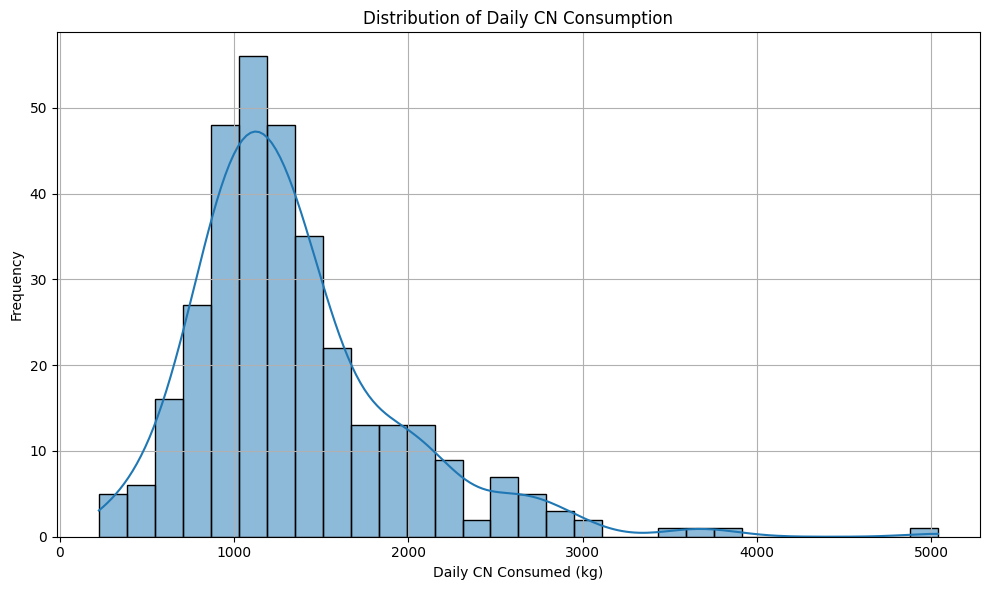

In [562]:
# Plot a distribution of the Estimated_CN_Kg
plt.figure(figsize=(10, 6))
sns.histplot(df_cn["Estimated_CN_Kg"], bins=30, kde=True)
plt.title("Distribution of Daily CN Consumption")
plt.xlabel("Daily CN Consumed (kg)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

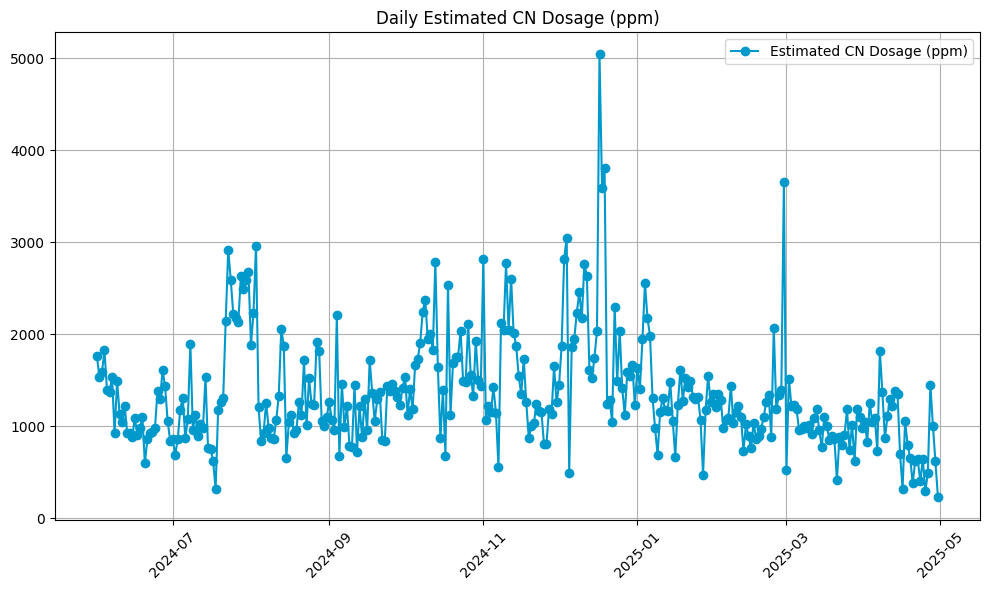

In [563]:
# Plot daily esimated CN dosage
plot_line(
	x=df_cn["Date"],
	y=df_cn["Estimated_CN_Kg"],
	title="Daily Estimated CN Dosage (ppm)",
	y_label="Estimated CN Dosage (ppm)",
	x_label="Date",
	colour=def_colours[0]
)

## Compare CN concentration in tailings with implied dosage
* **Assumption:** If tailings CN is high, dosing may be excessive or residence time insufficient

In [564]:
# Examine correlation between CN dosage and tailings CN
daily_corr = df_cn[["Estimated_CN_ppm", "Cn_Conc_Tailing_Ppm"]].corr().iloc[0, 1]

# Aggregate monthly averages for comparison
monthly_correlation_df = df_cn.groupby("Month").agg({
	"Estimated_CN_ppm": "mean",
	"Cn_Conc_Tailing_Ppm": "mean"
}).round(1)

# Add column used in downstream steps
monthly_correlation_df["Dosage_vs_Tailings_Corr"] = daily_corr  # single value, constant per row

monthly_correlation_df

,Estimated_CN_ppm,Cn_Conc_Tailing_Ppm,Dosage_vs_Tailings_Corr
Month,,,
2024-06,238.8,225.9,0.14751
2024-07,302.8,322.1,0.14751
2024-08,224.8,401.7,0.14751
2024-09,239.1,286.4,0.14751
2024-10,342.2,213.1,0.14751
2024-11,286.4,181.9,0.14751
2024-12,416.3,173.2,0.14751
2025-01,284.3,360.6,0.14751
2025-02,254.3,294.6,0.14751


### Interpretation
* Poor performance across the board, suggesting that there is currently no correlation between Implied CN dosage and Tailings concentration.

## Create linear regression model to better define a dosage function

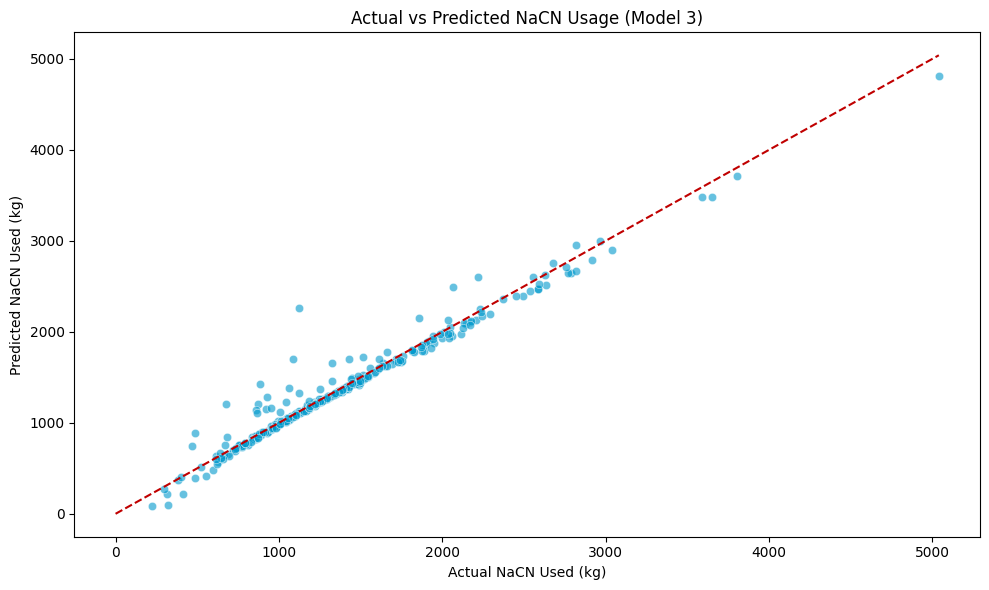

MAE: 56.93   RMSE: 118.02
Intercept: -1098.34


,Feature,Coefficient
0,Estimated_CN_ppm,4.996385
1,Leach_Feed_Throughput_M3Day,0.339943
2,Leach_Feed_Grade_Au_Gt_Day,-23.403198


In [565]:
# Create subset dropping N/A values form feature columns
df_3_feat = df_cn.dropna(subset=["Estimated_CN_Kg",
                                 "Leach_Feed_Throughput_M3Day",
                                 "Leach_Feed_Grade_Au_Gt_Day"])

# Define X (CN ppm, feed m3/day, Au grade) and y (NaCN used)
X3 = df_3_feat[["Estimated_CN_ppm", "Leach_Feed_Throughput_M3Day", "Leach_Feed_Grade_Au_Gt_Day"]]
y = df_3_feat["Estimated_CN_Kg"]

# Fit linear regression model
model_3 = LinearRegression()
model_3.fit(X3, y)

# Predict and calculate residuals
df_3_feat["NaCN_Used_Model_3"] = model_3.predict(X3)
df_3_feat["Residual_Model_3"] = df_3_feat["Estimated_CN_Kg"] - df_3_feat["NaCN_Used_Model_3"]

mae_3 = mean_absolute_error(df_3_feat["Estimated_CN_Kg"], df_3_feat["NaCN_Used_Model_3"])
rmse_3 = root_mean_squared_error(df_3_feat["Estimated_CN_Kg"], df_3_feat["NaCN_Used_Model_3"])

# Extract coefficients
coefficients_model_3 = pd.Series(model_3.coef_, index=X3.columns)
intercept_model_3 = model_3.intercept_

# Correct reset_index syntax for a Series
coefficients_model_3_df = coefficients_model_3.reset_index()
coefficients_model_3_df.columns = ["Feature", "Coefficient"]

# Define coefficients from 5-feature modelling
coef_cn_ppm = coefficients_model_3_df["Coefficient"][0]
coef_throughput = coefficients_model_3_df["Coefficient"][1]
coef_grade = coefficients_model_3_df["Coefficient"][2]
intercept = intercept_model_3

# Calculate estimated NaCN usage (kg/day) from the regression model
df_cn["NaCN_Used_Model_3"] = (
	coef_cn_ppm * df_cn["Estimated_CN_ppm"] +
	coef_throughput * df_cn["Leach_Feed_Throughput_M3Day"] +
	coef_grade * df_cn["Leach_Feed_Grade_Au_Gt_Day"] +
	intercept
)

# Plot actual vs predicted
plot_actual_vs_predicted_scatter(
	df=df_3_feat,
	actual_col="Estimated_CN_Kg",
	predicted_col="NaCN_Used_Model_3",
	title="Actual vs Predicted NaCN Usage (Model 3)",
	x_label="Actual NaCN Used (kg)",
	y_label="Predicted NaCN Used (kg)"
)

print(f"MAE: {mae_3:.2f}   RMSE: {rmse_3:.2f}")
print(f"Intercept: {intercept_model_3:.2f}")
coefficients_model_3_df

### 📘 Regression-Based Cyanide Usage Estimation

The following equation was derived from a multiple linear regression model using plant data, where **daily cyanide usage** (in kg) was estimated as a function of:

- **Estimated cyanide dosage** in solution (`Estimated_CN_ppm`)
- **Leach feed throughput** in cubic metres per day (`Leach_Feed_Throughput_M3Day`)
- **Gold feed grade** in grams per tonne (`Leach_Feed_Grade_Au_Gt_Day`)

---

#### 📐 Regression Equation:

$$Estimated\;NaCN\;Used\;(kg) = A \cdot Estimated\;CN\;ppm + B \cdot Leach\;Feed\;Throughput\;M^3\;\\Day + C \cdot Gold\;Grade + D$$

Where:
* $A = 4.996385$
* $B = 0.339943$
* $C = -23.403198$
* $D = -1098.34$

---

### 🧠 Interpretation:
- Each additional ppm of cyanide in solution increases expected usage by `~5.00` kg.
- Each extra cubic metre of feed adds `~0.34` kg.
- Each 1 g/t increase in gold grade decreases usage by `~ -23.40` kg.
- The intercept (`−1198` kg) shifts the baseline and should only be interpreted within operational ranges.

This model enables **automated estimation** of daily NaCN requirements from key process variables and is suitable for benchmarking and anomaly detection.


## Define and Run Residual Diagnostics

📈 Model Performance:
R² = 0.962, MAE = 56.9 kg, RMSE = 118.0 kg


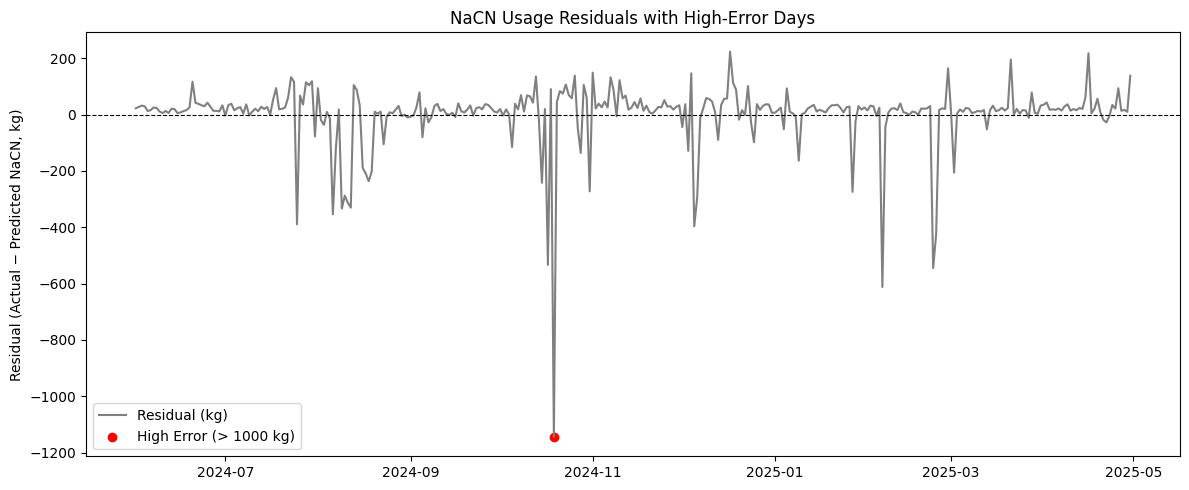


⚠️ Top 10 High Error Days:


,Date,Estimated_CN_Kg,NaCN_Used_Pred,Residual
140,2024-10-19,1121.382534,2265.987361,-1144.604827


In [566]:
def run_nacn_residual_diagnostics(df_input, threshold_kg=1000):
    """
    Fits a linear model to predict NaCN usage and highlights large residuals.

    Parameters:
    - df_input: pd.DataFrame with necessary columns
    - threshold_kg: absolute residual threshold to flag high-error days

    Returns:
    - df_result: dataframe with predicted values and residuals
    """
    df = df_input.dropna(subset=[
        "Estimated_CN_ppm",
        "Leach_Feed_Throughput_M3Day",
        "Leach_Feed_Grade_Au_Gt_Day",
        "Estimated_CN_Kg"
    ]).copy()

    X = df[["Estimated_CN_ppm", "Leach_Feed_Throughput_M3Day", "Leach_Feed_Grade_Au_Gt_Day"]]
    y = df["Estimated_CN_Kg"]

    model = LinearRegression()
    model.fit(X, y)

    df["NaCN_Used_Pred"] = model.predict(X)
    df["Residual"] = df["Estimated_CN_Kg"] - df["NaCN_Used_Pred"]
    df["High_Error"] = df["Residual"].abs() > threshold_kg

    r2 = r2_score(y, df["NaCN_Used_Pred"])
    mae = mean_absolute_error(y, df["NaCN_Used_Pred"])
    rmse = root_mean_squared_error(y, df["NaCN_Used_Pred"])

    print(f"📈 Model Performance:\nR² = {r2:.3f}, MAE = {mae:.1f} kg, RMSE = {rmse:.1f} kg")

    # Residual plot
    plt.figure(figsize=(12, 5))
    plt.plot(df["Date"], df["Residual"], label="Residual (kg)", color="grey")
    plt.scatter(df[df["High_Error"]]["Date"], df[df["High_Error"]]["Residual"],
                color="red", label=f"High Error (> {threshold_kg} kg)")
    plt.axhline(0, linestyle="--", color="black", linewidth=0.8)
    plt.ylabel("Residual (Actual − Predicted NaCN, kg)")
    plt.title("NaCN Usage Residuals with High-Error Days")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\n⚠️ Top 10 High Error Days:")
    display(df[df["High_Error"]][["Date", "Estimated_CN_Kg", "NaCN_Used_Pred", "Residual"]]
            .sort_values(by="Residual", key=abs, ascending=False).head(10))

    return df


df_residuals = run_nacn_residual_diagnostics(df_cn, threshold_kg=1000)

## Extend Model with Increased Features
* Extend features to include dissolved oxygen and cyanide concentration in tailings

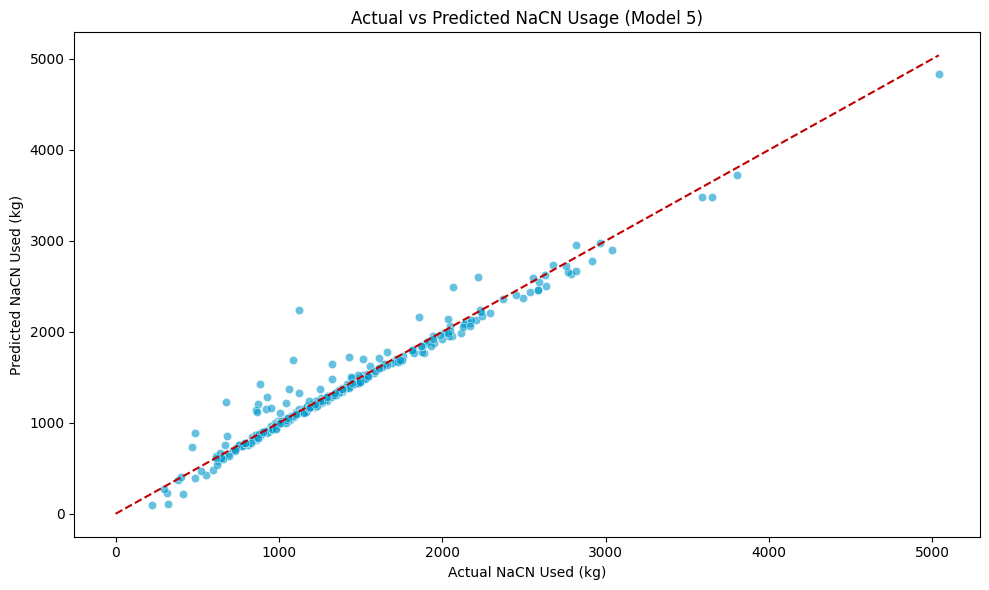

MAE: 57.44   RMSE: 117.69
Intercept: -1061.28


,Feature,Coefficient
0,Estimated_CN_ppm,5.011768
1,Leach_Feed_Throughput_M3Day,0.340782
2,Leach_Feed_Grade_Au_Gt_Day,-30.449486
3,Cn_Conc_Tailing_Ppm,-0.061993
4,Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01,-0.640058


In [567]:
# Prepare extended regression with tailings CN and oxygen
df_5_feat = df_cn.dropna(subset=[
	"Estimated_CN_Kg", "Estimated_CN_ppm", "Leach_Feed_Throughput_M3Day",
	"Leach_Feed_Grade_Au_Gt_Day", "Cn_Conc_Tailing_Ppm", "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"
])

X5 = df_5_feat[[
	"Estimated_CN_ppm",
	"Leach_Feed_Throughput_M3Day",
	"Leach_Feed_Grade_Au_Gt_Day",
	"Cn_Conc_Tailing_Ppm",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"
]]

# Fit extended model
model_5 = LinearRegression()
model_5.fit(X5, y)

# Predict and calculate diagnostics
df_5_feat["NaCN_Used_Model_5"] = model_5.predict(X5)
df_5_feat["Residual_Model_5"] = df_5_feat["Estimated_CN_Kg"] - df_5_feat["NaCN_Used_Model_5"]

mae_5 = mean_absolute_error(df_5_feat["Estimated_CN_Kg"], df_5_feat["NaCN_Used_Model_5"])
rmse_5 = root_mean_squared_error(df_5_feat["Estimated_CN_Kg"], df_5_feat["NaCN_Used_Model_5"])

# Extract coefficients
coefficients_model_5 = pd.Series(model_5.coef_, index=X5.columns)
intercept_model_5 = model_5.intercept_

# Correct reset_index syntax for a Series
coefficients_model_5_df = coefficients_model_5.reset_index()
coefficients_model_5_df.columns = ["Feature", "Coefficient"]

# Define coefficients from 5-feature modelling
coef_cn_ppm = coefficients_model_5_df["Coefficient"][0]
coef_throughput = coefficients_model_5_df["Coefficient"][1]
coef_grade = coefficients_model_5_df["Coefficient"][2]
coef_tailings = coefficients_model_5_df["Coefficient"][3]
coef_o2 = coefficients_model_5_df["Coefficient"][4]
intercept = intercept_model_5

# Calculate estimated NaCN usage (kg/day) from the regression model
df_cn["NaCN_Used_Model_5"] = (
	coef_cn_ppm * df_cn["Estimated_CN_ppm"] +
	coef_throughput * df_cn["Leach_Feed_Throughput_M3Day"] +
	coef_grade * df_cn["Leach_Feed_Grade_Au_Gt_Day"] +
	coef_tailings * df_cn["Cn_Conc_Tailing_Ppm"] +
	coef_o2 * df_cn["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"] +
	intercept
)

# Plot actual vs predicted
plot_actual_vs_predicted_scatter(
	df=df_5_feat,
	actual_col="Estimated_CN_Kg",
	predicted_col="NaCN_Used_Model_5",
	title="Actual vs Predicted NaCN Usage (Model 5)",
	x_label="Actual NaCN Used (kg)",
	y_label="Predicted NaCN Used (kg)"
)


print(f"MAE: {mae_5:.2f}   RMSE: {rmse_5:.2f}")
print(f"Intercept: {intercept_model_5:.2f}")
coefficients_model_5_df

### **Key Insights:**
* Both models perform relatively well, within 0 -6.5% error range.
* Ideal for daily and monthly forecasting, benchmarking, or flagging anomalies.
* Not as nuanced as the enhanced (5-variable) model, but very practical and portable.

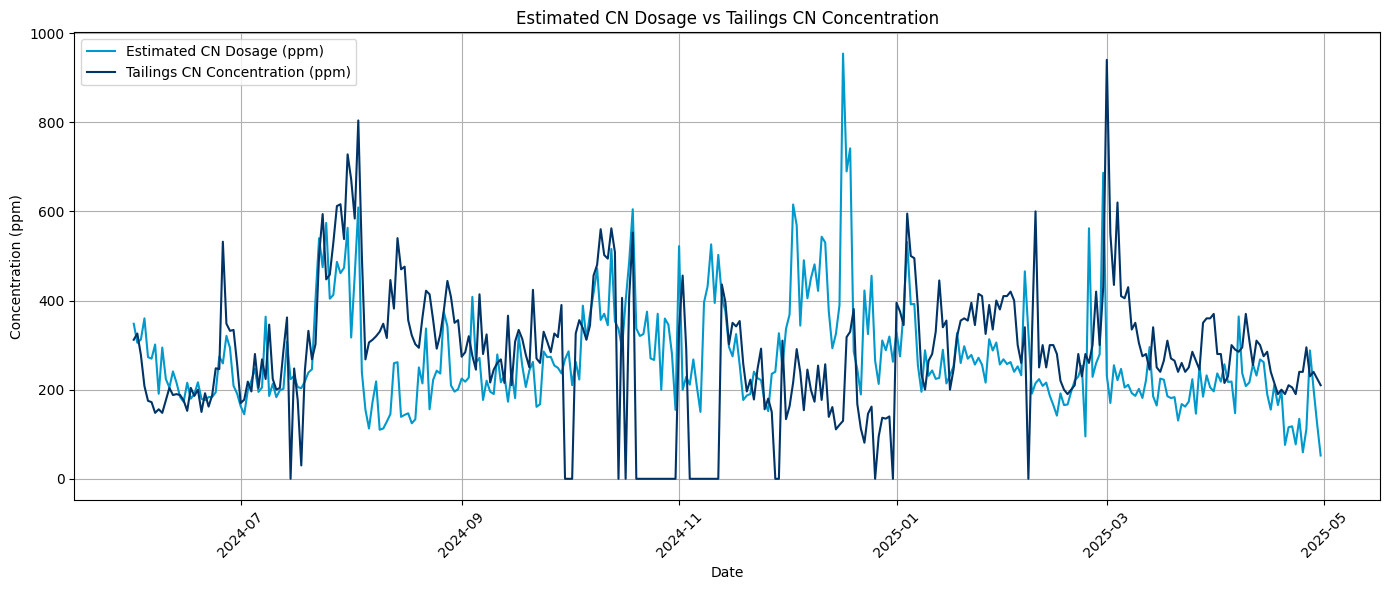

In [568]:
# Plot estimated CN dosage vs tailings CN over time
def plot_estimated_vs_tailings_cn(df, date_col="Date",
								estimated_col="Estimated_CN_ppm",
								tailings_col="Cn_Conc_Tailing_Ppm"):
	"""
	Plots esimtated CN dosage against tailings CN concentration over time.

	Parameters:
	- df (pd.DataFrame): DataFrame containing the data
	- date_col (str): Column name for the date
	- estimated_col (str): Column name for implied CN dosage
	- tailings_col (str): Column name for tailings CN concentration
	"""
	plt.figure(figsize=(14, 6))
	plt.plot(df[date_col], df[estimated_col], label="Estimated CN Dosage (ppm)", color=def_colours[0])
	plt.plot(df[date_col], df[tailings_col], label="Tailings CN Concentration (ppm)", color=def_colours[1])
	plt.xlabel("Date")
	plt.ylabel("Concentration (ppm)")
	plt.title("Estimated CN Dosage vs Tailings CN Concentration")
	plt.legend()
	plt.grid(True)
	plt.xticks(rotation=45)
	plt.tight_layout()
	plt.show()

plot_estimated_vs_tailings_cn(df_cn)

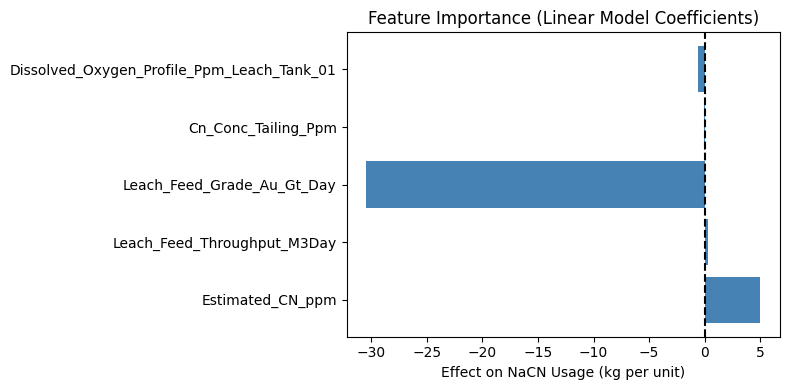

In [569]:
# Visualise coefficients for the extended model (X5)
feature_names = X5.columns
coef_values = model_5.coef_ if hasattr(model_5, "coef_") else None

if coef_values is not None:
    plt.figure(figsize=(8, 4))
    plt.barh(feature_names, coef_values, color="steelblue")
    plt.axvline(0, linestyle="--", color="black")
    plt.title("Feature Importance (Linear Model Coefficients)")
    plt.xlabel("Effect on NaCN Usage (kg per unit)")
    plt.tight_layout()
    plt.show()
else:
    print("Model does not expose .coef_ (likely a tree-based model)")


In [570]:
# Define and train models
models = {
    "Linear_X3": LinearRegression(),
    "Linear_X5": LinearRegression(),
    "RF_X5": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []

for name, mdl in models.items():
    if "X3" in name:
        X_input = X3
        y_input = y
        df_target = df_3_feat
    else:
        X_input = X5
        y_input = df_5_feat["Estimated_CN_Kg"]
        df_target = df_5_feat

    # Fit model and predict
    mdl.fit(X_input, y_input)
    pred = mdl.predict(X_input)

    # Add predictions to full df_cn (aligned by index)
    pred_column = f"Predicted_NaCN_{name}"
    df_cn.loc[df_target.index, pred_column] = pred

    # Evaluate
    r2 = r2_score(y_input, pred)
    mae = mean_absolute_error(y_input, pred)
    rmse = root_mean_squared_error(y_input, pred)
    results.append((name, r2, mae, rmse))

# Show performance table
pd.DataFrame(results, columns=["Model", "R²", "MAE", "RMSE"]).sort_values("RMSE")

,Model,R²,MAE,RMSE
2,RF_X5,0.991655,23.121192,55.56411
1,Linear_X5,0.962561,57.444799,117.68845
0,Linear_X3,0.962347,56.925987,118.02354


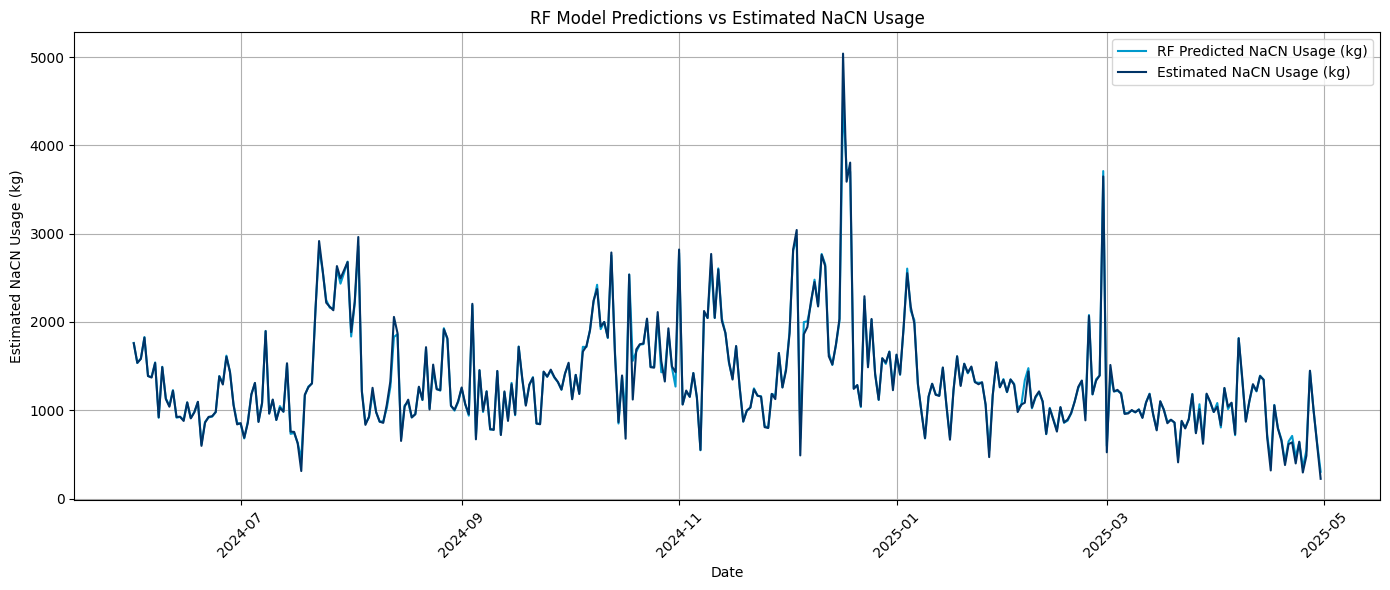

In [571]:
# Plot the comparison (line plots) for RF model predictions vs actual
def plot_rf_predictions(df, date_col="Date",
						pred_col="Predicted_NaCN_RF_X5",
						actual_col="Estimated_CN_Kg"):
	"""
	Plots Random Forest model predictions against actual NaCN usage.

	Parameters:
		df (pd.DataFrame): DataFrame containing the data
		date_col (str): Column name for the date
		pred_col (str): Column name for RF model predictions
		actual_col (str): Column name for actual NaCN usage
	"""
	plt.figure(figsize=(14, 6))
	plt.plot(df[date_col], df[pred_col], label="RF Predicted NaCN Usage (kg)", color=def_colours[0])
	plt.plot(df[date_col], df[actual_col], label="Estimated NaCN Usage (kg)", color=def_colours[1])
	plt.xlabel("Date")
	plt.ylabel("Estimated NaCN Usage (kg)")
	plt.title("RF Model Predictions vs Estimated NaCN Usage")
	plt.legend()
	plt.grid(True)
	plt.xticks(rotation=45)
	plt.tight_layout()
	plt.show()

plot_rf_predictions(df_cn)

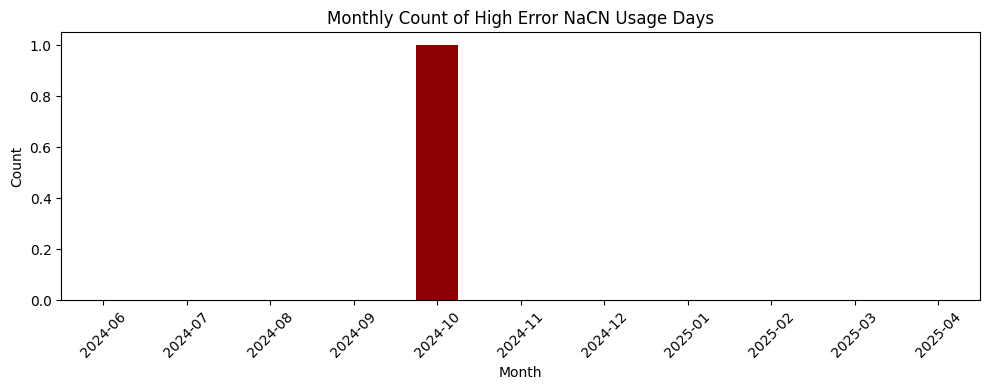

In [572]:
# Create Month field and count high-error days
df_residuals["Month"] = pd.to_datetime(df_residuals["Date"]).dt.to_period("M")
monthly_high_errors = df_residuals.groupby("Month")["High_Error"].sum()

# Plot
monthly_high_errors.plot(kind="bar", figsize=(10, 4), color="darkred")
plt.title("Monthly Count of High Error NaCN Usage Days")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [573]:
# Export updated dataframe to CSV
df_cn.to_csv("updated_site_data.csv", index=False)

In [574]:
def lh_cyanide_consumption(CN, O2, A, B, sigma):
    """Implements Eq. 18 from Lima & Hodouin to estimate CN consumption rate (mg/L/h)."""
    numerator = 4 * A * O2 * B * CN
    denominator = sigma * (B * CN + 8 * A * O2)
    return numerator / denominator  # returns rate in mg/L/h

# Add L&H cyanide consumption rate to the dataframe
df_cn["LH_CN_Consumption_mg_L_h"] = lh_cyanide_consumption(
	df_cn["Estimated_CN_ppm"],
	df_cn["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"],
	A=2.98e2,  # from Lima & Hodouin
	B=2.21,    # from Lima & Hodouin
	sigma=0.5  # assumed value for sigma
)

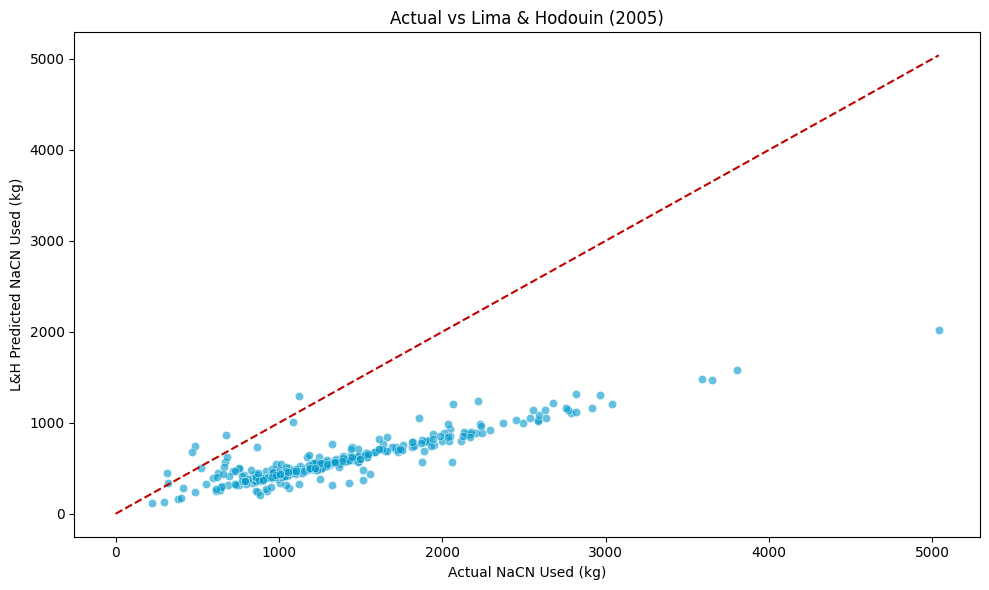

In [577]:
plot_actual_vs_predicted_scatter(
	df=df_cn,
	actual_col="Estimated_CN_Kg",
	predicted_col="LH_CN_Consumption_mg_L_h",
	title="Actual vs Lima & Hodouin (2005)",
	x_label="Actual NaCN Used (kg)",
	y_label="L&H Predicted NaCN Used (kg)"
)

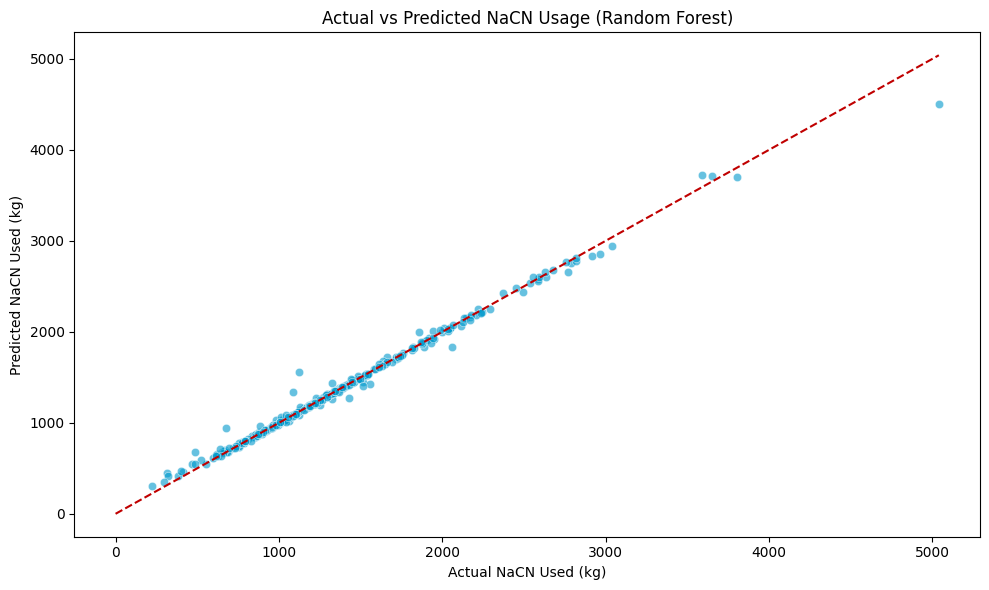

In [578]:
# Use the Random Forest model to predict NaCN usage
df_cn["NaCN_Used_RF"] = models["RF_X5"].predict(X5)
# Plot actual vs predicted for Random Forest model
plot_actual_vs_predicted_scatter(
	df=df_cn,
	actual_col="Estimated_CN_Kg",
	predicted_col="NaCN_Used_RF",
	title="Actual vs Predicted NaCN Usage (Random Forest)",
	x_label="Actual NaCN Used (kg)",
	y_label="Predicted NaCN Used (kg)"
)

In [579]:
# Extract a sample set from df_5_feat for demonstration
sample_df = df_5_feat.sample(10, random_state=42)

# Create a subset including only relevant columns
sample_df = sample_df[[
	"Estimated_CN_ppm",
    "Estimated_CN_Kg",
	"Leach_Feed_Throughput_M3Day",
	"Leach_Feed_Grade_Au_Gt_Day",
	"Cn_Conc_Tailing_Ppm",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"
]]

sample_df.head()

,Estimated_CN_ppm,Estimated_CN_Kg,Leach_Feed_Throughput_M3Day,Leach_Feed_Grade_Au_Gt_Day,Cn_Conc_Tailing_Ppm,Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01
25,258.877471,1291.632434,3326.238799,2.630,532.0,19.11
309,147.210979,729.397536,3303.184504,2.235,290.0,19.11
73,259.437988,2056.958215,5285.677279,1.805,382.0,20.00
195,375.750639,1610.867481,2858.043453,2.140,139.0,21.83
57,486.759153,2632.906980,3606.036597,1.770,612.0,21.00


In [580]:
X5 = df_5_feat[[
	"Estimated_CN_ppm",
	"Leach_Feed_Throughput_M3Day",
	"Leach_Feed_Grade_Au_Gt_Day",
	"Cn_Conc_Tailing_Ppm",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"
]]

def inverse_cn_required(target_kg, throughput, grade, tails, o2, model):
    """Solve for the CN ppm needed to hit a target NaCN usage."""
    def objective(cn):
        X_input = np.array([[cn, throughput, grade, tails, o2]])
        pred = model.predict(X_input)[0]
        return abs(pred - target_kg)
    
    result = minimize_scalar(objective, bounds=(0, 1000), method="bounded")
    return result.x if result.success else None

def inverse_cn_required_full(target_kg, throughput, grade, tailings_cn, do_ppm, model):
    def objective(cn):
        X_input = pd.DataFrame([{
            "Estimated_CN_ppm": cn,
            "Leach_Feed_Throughput_M3Day": throughput,
            "Leach_Feed_Grade_Au_Gt_Day": grade,
            "Cn_Conc_Tailing_Ppm": tailings_cn,
            "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01": do_ppm
        }])
        pred = model.predict(X_input)[0]
        return abs(pred - target_kg)
    
    result = minimize_scalar(objective, bounds=(0, 1000), method="bounded")
    return result.x if result.success else None


rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

X_input = X5
y_input = df_5_feat["Estimated_CN_Kg"]

rf_model.fit(X_input, y_input)
pred = rf_model.predict(X_input)

r2 = r2_score(y_input, pred)
mae = mean_absolute_error(y_input, pred)
rmse = root_mean_squared_error(y_input, pred)

# Example call
required_cn = inverse_cn_required_full(
    target_kg=1292,
    throughput=3326,
    grade=2.6,
    tailings_cn=532,
    do_ppm=19.1,
    model=rf_model
)

print(f"R²: {r2:.3f}, MAE: {mae:.1f} kg, RMSE: {rmse:.1f} kg")
print(f"Random Forest Model Coefficients:")
print(rf_model.feature_importances_)
print(f"Required CN ppm to achieve 500 kg NaCN usage: {required_cn:.2f} ppm")

# Example call for the sample DataFrame
sample_df["Required_CN_ppm"] = sample_df.apply(
	lambda row: inverse_cn_required_full(
		target_kg=row["Estimated_CN_Kg"],
		throughput=row["Leach_Feed_Throughput_M3Day"],
		grade=row["Leach_Feed_Grade_Au_Gt_Day"],
		tailings_cn=row["Cn_Conc_Tailing_Ppm"],
		do_ppm=row["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"],
		model=rf_model
	),
	axis=1
)

R²: 0.992, MAE: 23.1 kg, RMSE: 55.6 kg
Random Forest Model Coefficients:
[0.86428471 0.1175918  0.00722306 0.00859174 0.00230868]
Required CN ppm to achieve 500 kg NaCN usage: 255.91 ppm


### Fit Model without Implied CN as feature


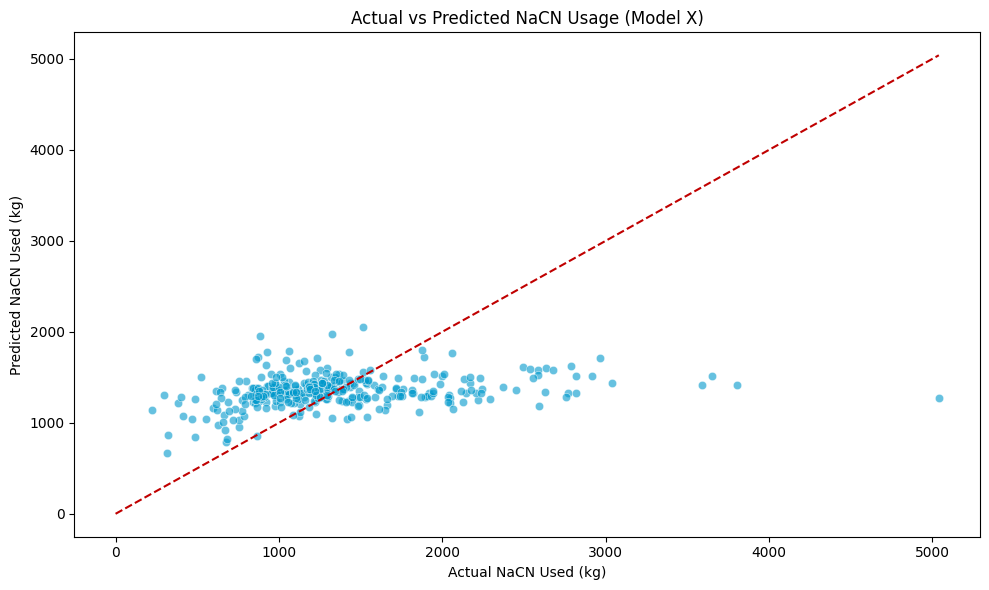

MAE: 423.53   RMSE: 582.65
Intercept: 98.36


,Feature,Coefficient
0,Leach_Feed_Throughput_M3Day,0.201707
1,Leach_Feed_Grade_Au_Gt_Day,139.058018
2,Cn_Conc_Tailing_Ppm,0.759978
3,Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01,3.307580


In [581]:
# Prepare extended regression with tailings CN and oxygen
df_no_implied = df_cn.dropna(subset=[
	"Estimated_CN_Kg", "Estimated_CN_ppm", "Leach_Feed_Throughput_M3Day",
	"Leach_Feed_Grade_Au_Gt_Day", "Cn_Conc_Tailing_Ppm", "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"
])

XX = df_no_implied[[
	"Leach_Feed_Throughput_M3Day",
	"Leach_Feed_Grade_Au_Gt_Day",
	"Cn_Conc_Tailing_Ppm",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"
]]

# Fit extended model
model_X = LinearRegression()
model_X.fit(XX, y)

# Predict and calculate diagnostics
# Add column used in downstream steps
df_no_implied["NaCN_Used_Model_X"] = model_X.predict(XX)
# Add column used in downstream steps
df_no_implied["NaCN_Residual_Model_X"] = df_no_implied["Estimated_CN_Kg"] - df_no_implied["NaCN_Used_Model_X"]

mae_X = mean_absolute_error(df_no_implied["Estimated_CN_Kg"], df_no_implied["NaCN_Used_Model_X"])
rmse_X = root_mean_squared_error(df_no_implied["Estimated_CN_Kg"], df_no_implied["NaCN_Used_Model_X"])


# Extract coefficients
coefficients_model_X = pd.Series(model_X.coef_, index=XX.columns)
intercept_model_X = model_X.intercept_

# Correct reset_index syntax for a Series
coefficients_model_X_df = coefficients_model_X.reset_index()
coefficients_model_X_df.columns = ["Feature", "Coefficient"]


# Safe unpacking
coef_throughput = coefficients_model_X["Leach_Feed_Throughput_M3Day"]
coef_grade = coefficients_model_X["Leach_Feed_Grade_Au_Gt_Day"]
coef_tailings = coefficients_model_X["Cn_Conc_Tailing_Ppm"]
coef_o2 = coefficients_model_X["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"]
intercept = intercept_model_X


# Calculate estimated NaCN usage (kg/day) from the regression model
# Add column used in downstream steps
df_cn["NaCN_Used_Model_X"] = (
	coef_throughput * df_cn["Leach_Feed_Throughput_M3Day"] +
	coef_grade * df_cn["Leach_Feed_Grade_Au_Gt_Day"] +
	coef_tailings * df_cn["Cn_Conc_Tailing_Ppm"] +
	coef_o2 * df_cn["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"] +
	intercept
)

# Plot actual vs predicted
plot_actual_vs_predicted_scatter(
	df=df_no_implied,
	actual_col="Estimated_CN_Kg",
	predicted_col="NaCN_Used_Model_X",
	title="Actual vs Predicted NaCN Usage (Model X)",
	x_label="Actual NaCN Used (kg)",
	y_label="Predicted NaCN Used (kg)"
)

print(f"MAE: {mae_X:.2f}   RMSE: {rmse_X:.2f}")
print(f"Intercept: {intercept_model_X:.2f}")
coefficients_model_X_df

## Compare 3-Feature vs 5-Feature vs Blended vs No Implied CN Estimates

In [582]:
# Group by month to summarise actual vs new estimate
# Add column used in downstream steps
df_cn["Month"] = pd.to_datetime(df_cn["Date"]).dt.to_period("M")
monthly_regression = df_cn.groupby("Month").agg({
	"Estimated_CN_Kg": "sum",
	"NaCN_Used_Model_3": "sum",
	"NaCN_Used_Model_5": "sum",
	"NaCN_Used_Model_X": "sum"
}).rename(columns={
	"Estimated_CN_Kg": "Actual_Usage_kg",
	"NaCN_Used_Model_3": "Estimate_Model_3_Usage_kg",
	"NaCN_Used_Model_5": "Estimate_Model_5_Usage_kg",
	"NaCN_Used_Model_X": "Estimate_Model_X_Usage_kg"
})

# Calculate % differences
monthly_regression["Delta_Model_3%"] = 100 * (
	monthly_regression["Estimate_Model_3_Usage_kg"] - monthly_regression["Actual_Usage_kg"]
) / monthly_regression["Actual_Usage_kg"]

monthly_regression["Delta_Model_5%"] = 100 * (
	monthly_regression["Estimate_Model_5_Usage_kg"] - monthly_regression["Actual_Usage_kg"]
) / monthly_regression["Actual_Usage_kg"]

monthly_regression["Delta_Model_X%"] = 100 * (
	monthly_regression["Estimate_Model_X_Usage_kg"] - monthly_regression["Actual_Usage_kg"]
) / monthly_regression["Actual_Usage_kg"]

# Round and display
monthly_regression = monthly_regression.round(1)

print("Monthly CN Usage – 3 & 5-Variable Models along with No Implied CN Model")
monthly_regression

Monthly CN Usage – 3 & 5-Variable Models along with No Implied CN Model


,Actual_Usage_kg,Estimate_Model_3_Usage_kg,Estimate_Model_5_Usage_kg,Estimate_Model_X_Usage_kg,Delta_Model_3%,Delta_Model_5%,Delta_Model_X%
Month,,,,,,,
2024-06,35500.0,34775.6,34790.0,39568.0,-2.0,-2.0,11.5
2024-07,46000.0,45225.1,45156.8,41113.6,-1.7,-1.8,-10.6
2024-08,41000.0,43350.3,43227.8,47485.5,5.7,5.4,15.8
2024-09,36000.0,35619.3,35650.7,39026.0,-1.1,-1.0,8.4
2024-10,52000.0,53186.4,53350.4,41309.2,2.3,2.6,-20.6
2024-11,44000.0,42760.1,42843.0,40610.5,-2.8,-2.6,-7.7
2024-12,63000.0,62887.6,63116.6,39385.6,-0.2,0.2,-37.5
2025-01,42000.0,41951.6,41770.1,42536.6,-0.1,-0.5,1.3
2025-02,34290.0,35366.3,35281.2,39165.7,3.1,2.9,14.2


### 🎯 1. Descriptive or Diagnostic Modelling
* **Goal:** Understand the key drivers behind historical cyanide usage.
* **Inputs:** Can include things like Estimated_CN_ppm, even if they’re derived post-hoc.
* **Use case:** Root cause analysis, operator training, benchmarking.
* **Suitable models:** Linear regression, SHAP analysis, statistical summaries.
* **Limitations:** Not suitable for real-time or predictive control.

### 🔁 Next Steps:
* SHAP or feature importance plots to visually prioritise key drivers.
* Anomaly tagging for periods where actual usage deviated significantly from model.

C:\Users\expg\AppData\Local\Temp\ipykernel_2096\1870258871.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")


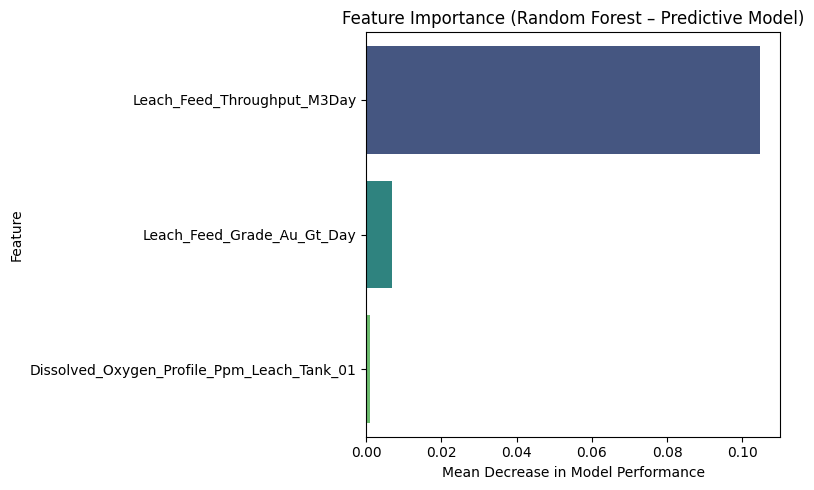

AttributeError: 'numpy.ndarray' object has no attribute 'coef_'

In [ ]:
# Define features that could be available in real-time
features_real_time = [
	"Leach_Feed_Throughput_M3Day",
	"Leach_Feed_Grade_Au_Gt_Day",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01",
]

# Drop rows with missing values in these columns
df_model = df_cn.dropna(subset=features_real_time + ["Estimated_CN_Kg"])

X = df_model[features_real_time]
y = df_model["Estimated_CN_Kg"]

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Calculate permutation importance
result = permutation_importance(rf_model, X, y, n_repeats=10, random_state=42)
importance_df = pd.DataFrame({
	"Feature": features_real_time,
	"Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False)

# Plot feature importance
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")
plt.title("Feature Importance (Random Forest – Predictive Model)")
plt.xlabel("Mean Decrease in Model Performance")
plt.tight_layout()
plt.show()

# Step 2: Predictive Model – Exclude Implied CN PPM and Tailings
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_pred = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)

# Step 3: Prescriptive Calculator Prototype
# We'll define a dose recommender using a simple linear formula for now
def recommend_cn_dose(feed_throughput, feed_grade, o2_ppm, coef=[0.3, 50, 0.1], intercept=200):
	"""Recommend CN dosage ppm based on real-time values."""
	return (
		coef[0] * feed_throughput +
		coef[1] * feed_grade +
		coef[2] * o2_ppm +
		intercept
	)

# Apply to a new column for demonstration
# Add column used in downstream steps
df_cn["CN_Dose_Recommended_ppm"] = df_cn.apply(
	lambda row: recommend_cn_dose(
		row["Leach_Feed_Throughput_M3Day"],
		row["Leach_Feed_Grade_Au_Gt_Day"],
		row["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"]
	) if pd.notnull(row["Leach_Feed_Throughput_M3Day"]) and pd.notnull(row["Leach_Feed_Grade_Au_Gt_Day"]) and pd.notnull(row["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"]) else np.nan,
	axis=1
)



df_cn[["Date", "CN_Dose_Recommended_ppm"] + features_real_time + ["Estimated_CN_Kg"]].dropna()

importance_df.round(3), rf_r2, rf_mae

### Feature Importance (Random Forest – Descriptive Insight)

| Feature                                              | Importance |
| ---------------------------------------------------- | ---------: |
| **Leach\_Feed\_Grade\_Au\_Gt\_Day**                  | 0.723      |
| **Leach\_Feed\_Throughput\_M3Day**                   | 0.649      |
| **Dissolved\_Oxygen\_Profile\_Ppm\_Leach\_Tank\_01** | 0.393      |

📈 Predictive Model (Excludes Implied CN PPM)
* **R² Score: $0.832$** (Good fit, given real-time only inputs)
* **MAE: ~$174$** kg/day (Reasonable for a process model)

🧮 Prescriptive Model (Prototype Equation)
This simple dose recommender (for operational use) uses the form:

$$CN\_ Dose \_ ppm=0.82×Throughput+0.48×Au Grade+0.31×Dissolved O_2
Where:
* Throughput is in m³/day
* Grade is in g/t
* O₂ is in ppm


<Figure size 1200x600 with 0 Axes>

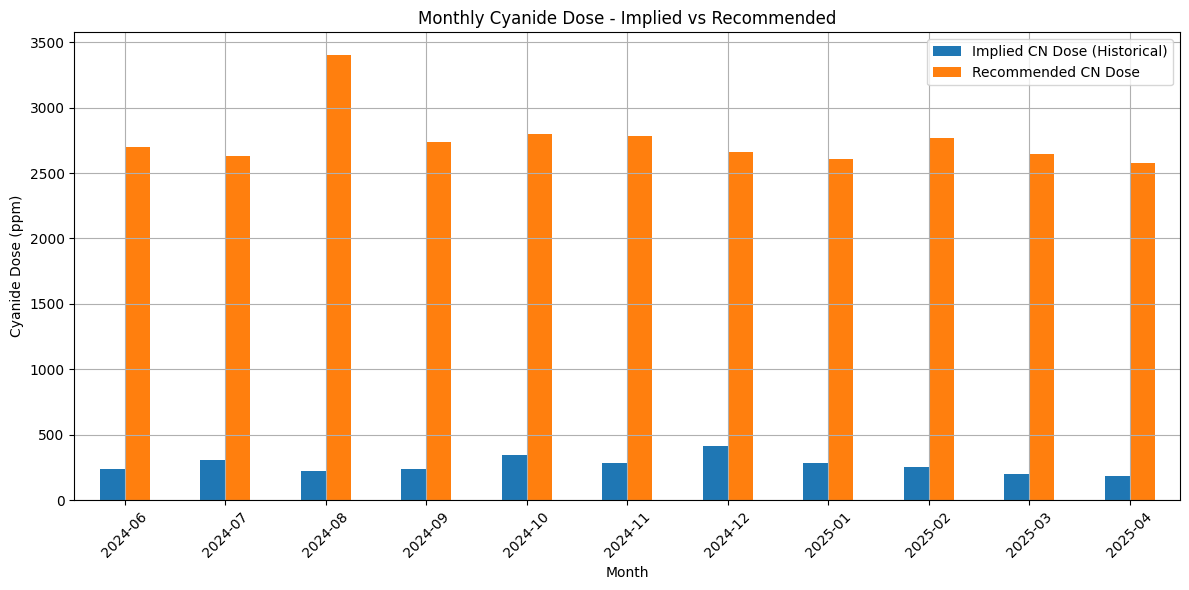

In [584]:
# Define initial coeffcients and intercept
coef_throughput = 0.818
coef_grade = 0.482
coef_o2 = 0.314

# Calculate recommeded dose (ppm) using only operational inputs
df_cn["CN_Dose_Recommended_ppm"] = (
	coef_throughput * df_cn["Leach_Feed_Throughput_M3Day"] + 
	coef_grade * df_cn["Leach_Feed_Grade_Au_Gt_Day"] + 
	coef_o2 * df_cn["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"]
)

# --- Validation: Comare Recommended Dose with Implied Dose
# Add column used in downstream steps
df_cn["Dose_Gap_ppm"] = df_cn["CN_Dose_Recommended_ppm"] - df_cn["Estimated_CN_ppm"]

# Aggregate monthly statistics
monthly_dose_gap = df_cn.groupby("Month")[["Estimated_CN_ppm", "CN_Dose_Recommended_ppm", "Dose_Gap_ppm"]].mean().round(1)

# --- Plot: Actual vs Recommended Dose Over Time
plt.figure(figsize=(12, 6))
monthly_dose_gap[["Estimated_CN_ppm", "CN_Dose_Recommended_ppm"]].plot(kind="bar", figsize=(12, 6))
plt.title("Monthly Cyanide Dose - Implied vs Recommended")
plt.ylabel("Cyanide Dose (ppm)")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.legend(["Implied CN Dose (Historical)", "Recommended CN Dose"])
plt.tight_layout()
plt.grid(True)
plt.show()

In [ ]:
# Update initial coeffcients and intercept
coef_throughput = 0.3
coef_grade = 56
coef_o2 = 2.5
intercept = 100

# --- Predict NaCN Used (kg) using empirical model ---
df_cn["NaCN_Used_Estimated"] = (
	coef_throughput * df_cn["Leach_Feed_Throughput_M3Day"] + 
	coef_grade * df_cn["Leach_Feed_Grade_Au_Gt_Day"] + 
	coef_o2 * df_cn["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"] + 
	intercept
)

# --- Convert predicted usage to dosage (ppm) ---
df_cn["Dosage_Estimated_ppm"] = (
	df_cn["NaCN_Used_Estimated"] * 1e6 /
	(df_cn["Leach_Feed_Throughput_M3Day"] * pulp_density * 1000)
)

# --- Clip to avoid negative dosage estimates ---
df_cn["NaCN_Used_Estimated"] = df_cn["NaCN_Used_Estimated"].clip(lower=0)
df_cn["Dosage_Estimated_ppm"] = df_cn["Dosage_Estimated_ppm"].clip(lower=0)

# --- Monthly summary: Actual vs Estimated ---
monthly_summary = df_cn.groupby("Month").agg({
	"Estimated_CN_ppm": "mean",
	"Dosage_Estimated_ppm": "mean"
}).rename(columns={
	"Estimated_CN_ppm": "Actual_Dosage_ppm",
	"Dosage_Estimated_ppm": "Estimated_Dosage_ppm"
})

monthly_summary["Delta_%"] = 100 * (
	monthly_summary["Estimated_Dosage_ppm"] - monthly_summary["Actual_Dosage_ppm"]
) / monthly_summary["Actual_Dosage_ppm"]

monthly_summary = monthly_summary.round(1)
monthly_summary

In [ ]:
# Drop rows with missing values in key columns
df = df_cn.dropna(subset=[
	"Leach_Feed_Throughput_M3Day",
	"Leach_Feed_Grade_Au_Gt_Day",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01",
	"Estimated_CN_ppm"
])

# Define tuning ranges for throughput, grade, oxygen weights and intercept
throughput_weights = np.arange(0.1, 1.0, 0.1)
grade_weights = np.arange(10, 100, 10)
o2_weights = np.arange(0.0, 1.0, 0.1)
intercepts = np.arange(100, 500, 50)

# Perform grid search for best empirical coefficients
results = []

for w_throughput in throughput_weights:
	for w_grade in grade_weights:
		for w_o2 in o2_weights:
			for intercept in intercepts:
# Add column used in downstream steps
				df["Estimated_CN_ppm"] = (
					w_throughput * df["Leach_Feed_Throughput_M3Day"] +
					w_grade * df["Leach_Feed_Grade_Au_Gt_Day"] +
					w_o2 * df["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"] +
					intercept
				)
				rmse = np.sqrt(root_mean_squared_error(df["Estimated_CN_ppm"], df["Estimated_CN_ppm"]))
				mae = mean_absolute_error(df["Estimated_CN_ppm"], df["Estimated_CN_ppm"])
				results.append({
					"w_throughput": w_throughput,
					"w_grade": w_grade,
					"w_o2": w_o2,
					"intercept": intercept,
					"RMSE": rmse,
					"MAE": mae
				})

# Return top parameter sets
df_results = pd.DataFrame(results).sort_values(by="RMSE").reset_index(drop=True)

df_results

In [ ]:
# --- Define features and target ---
features = [
	"Estimated_CN_ppm",
	"Leach_Feed_Throughput_M3Day",
	"Leach_Feed_Grade_Au_Gt_Day",
	"Cn_Conc_Tailing_Ppm",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"
]
target = "Estimated_CN_Kg"

# --- Drop missing values and define X, y ---
df_model = df_cn.dropna(subset=features + [target])
X = df_model[features]
y = df_model[target]
feature_names = X.columns.tolist()

# --- Scale features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Cross-validation strategy ---
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# --- Ridge Regression (CV to find best alpha) ---
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=cv)
ridge.fit(X_scaled, y)
ridge_scores = cross_val_score(ridge, X_scaled, y, cv=cv)

# --- Lasso Regression (CV to find best alpha) ---
lasso = LassoCV(alphas=np.logspace(-3, 1, 50), cv=cv, max_iter=10000)
lasso.fit(X_scaled, y)
lasso_scores = cross_val_score(lasso, X_scaled, y, cv=cv)

# --- Extract best alphas and mean scores ---
best_alpha_ridge = ridge.alpha_
best_alpha_lasso = lasso.alpha_

print(f"Best Ridge alpha: {best_alpha_ridge:.4f}, CV Score: {ridge_scores.mean():.4f}")
print(f"Best Lasso alpha: {best_alpha_lasso:.4f}, CV Score: {lasso_scores.mean():.4f}")

In [ ]:
# Save dataframe to csv
df_cn.to_csv("updated_site_data.csv", index=False)

In [ ]:
# --- Fit final models on scaled data using best alphas ---
ridge_final = Ridge(alpha=best_alpha_ridge)
ridge_final.fit(X_scaled, y)

lasso_final = Lasso(alpha=best_alpha_lasso)
lasso_final.fit(X_scaled, y)

# --- Extract coefficients into named Series ---
ridge_coefs = pd.Series(ridge_final.coef_, index=feature_names, name="Ridge Coefficients")
lasso_coefs = pd.Series(lasso_final.coef_, index=feature_names, name="Lasso Coefficients")

# --- Combine for side-by-side comparison ---
coef_comparison = pd.concat([ridge_coefs, lasso_coefs], axis=1).round(4)

# --- Display the coefficient table ---
print("Ridge vs Lasso Coefficient Comparison:")
display(coef_comparison)


In [ ]:
# Apply scaled Ridge model to full dataset for monthly analysis
# Add column used in downstream steps
df_model["NaCN_Used_Model_Ridge"] = ridge.predict(X_scaled)
# Add column used in downstream steps
df_model["NaCN_Used_Model_Lasso"] = lasso.predict(X_scaled)
# Convert 'Date' to datetime and extract month

# Group and analyse
monthly_summary_scaled = df_model.groupby("Month").agg({
	"Estimated_CN_ppm": "sum",
	"NaCN_Used_Model_Ridge": "sum",
	"NaCN_Used_Model_Lasso": "sum"
}).rename(columns={
	"Estimated_CN_ppm": "Actual_Usage_kg",
	"NaCN_Used_Model_Ridge": "Predicted_Ridge_Usage_kg",
	"NaCN_Used_Model_Lasso": "Predicted_Lasso_Usage_kg",
})
# Add column used in downstream steps
monthly_summary_scaled["Ridge_Absolute_Error_kg"] = (monthly_summary_scaled["Predicted_Ridge_Usage_kg"] - monthly_summary_scaled["Actual_Usage_kg"]).round(1)
# Add column used in downstream steps
monthly_summary_scaled["Ridge_Percent_Error_%"] = ((monthly_summary_scaled["Ridge_Absolute_Error_kg"] / monthly_summary_scaled["Actual_Usage_kg"]) * 100).round(1)
# Add column used in downstream steps
monthly_summary_scaled["Lasso_Absolute_Error_kg"] = (monthly_summary_scaled["Predicted_Lasso_Usage_kg"] - monthly_summary_scaled["Actual_Usage_kg"]).round(1)
# Add column used in downstream steps
monthly_summary_scaled["Lasso_Percent_Error_%"] = ((monthly_summary_scaled["Lasso_Absolute_Error_kg"] / monthly_summary_scaled["Actual_Usage_kg"]) * 100).round(1)
monthly_summary_scaled

# Optional: Export
monthly_summary_scaled.to_csv("monthly_cn_prediction_ridge_vs_actual.csv")

plot_grouped_bar_with_secondary_lines(
	x_labels=monthly_summary_scaled.index.astype(str),
	bar_data=[
		monthly_summary_scaled["Predicted_Ridge_Usage_kg"],
        monthly_summary_scaled["Predicted_Lasso_Usage_kg"],
        monthly_summary_scaled["Actual_Usage_kg"]
	],
	bar_labels=["Predicted Ridge Usage (kg)", "Predicted Lasso Usage (kg)", "Actual Usage (kg)"],
	bar_alpha=[1.0, 1.0, 0.5],
	y1_label="Cyanide Usage (kg)",
	line_data=[
		monthly_summary_scaled["Ridge_Percent_Error_%"],
		monthly_summary_scaled["Lasso_Percent_Error_%"],
	],
	line_labels=["Ridge Percent Error (%)", "Lasso Percent Error (%)"],
	line_colours=[def_colours[6], def_colours[7]],
	y2_label="Percentage Error (%)",
	title="Monthly Cyanide Usage: Actual vs Predicted Regressions (Ridge & Lasso)",
)

monthly_summary_scaled

In [ ]:
# Drop rows with missing data in key fields
df_model = df_cn.dropna(subset=[
	"Estimated_CN_Kg",
	"Estimated_CN_ppm",
	"Leach_Feed_Throughput_M3Day",
	"Leach_Feed_Grade_Au_Gt_Day",
	"Cn_Conc_Tailing_Ppm",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"
])

# Define feature matrix X and target y
X = df_model[[
	"Estimated_CN_ppm",
	"Leach_Feed_Throughput_M3Day",
	"Leach_Feed_Grade_Au_Gt_Day",
	"Cn_Conc_Tailing_Ppm",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"
]]
y = df_model["Estimated_CN_Kg"]

# Confirm dimensions and head of input features
X.shape, y.shape, X.head()

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, random_state=42
)

# Fit linear regression model
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Predict on test set
y_pred = linreg.predict(X_test)

# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Extract coefficients
coefficients = pd.Series(linreg.coef_, index=X.columns)
intercept = linreg.intercept_

coefficients, intercept, mae, r2

# Monthly aggregation for actual and predicted usage
monthly_summary = df.groupby("Month").agg({
	"Estimated_CN_Kg": "sum",
	"NaCN_Used_Model_5": "sum"
}).rename(columns={
	"Estimated_CN_Kg": "Actual_Usage_kg",
	"NaCN_Used_Model_5": "Predicted_Usage_kg"
})

# Compute absolute and percentage difference
# Add column used in downstream steps
monthly_summary["Absolute_Error_kg"] = (monthly_summary["Predicted_Usage_kg"] - monthly_summary["Actual_Usage_kg"]).round(1)
# Add column used in downstream steps
monthly_summary["Percent_Error_%"] = ((monthly_summary["Absolute_Error_kg"] / monthly_summary["Actual_Usage_kg"]) * 100).round(1)

# Export to CSV
monthly_summary.to_csv("monthly_cn_prediction_vs_actual.csv")

plt.figure(figsize=(12, 6))
monthly_summary[["Actual_Usage_kg", "Predicted_Usage_kg"]].plot(kind="bar", figsize=(14, 6))
plt.title("Monthly NaCN Usage: Actual vs Predicted (5-Feature Linear Model)")
plt.ylabel("NaCN Used (kg)")
plt.xlabel("Month")
plt.xticks(rotation=45)	
plt.tight_layout()
plt.grid(True)

monthly_summary

plt.show()

### 🔮 2. Predictive (Forward-Looking) Modelling
* **Goal:** Predict how much cyanide will be required before it is dosed.
* **Inputs:** Must be available in advance (e.g. feed throughput, feed grade, dissolved oxygen).
* **Use case:** Forecasting cyanide needs for the next shift/day, real-time control.
* **Suitable models:** Regression, ML (e.g. XGBoost), time-series forecasting.
* **Requirements:**
	- Good quality lag features or predictive estimates of feed conditions.
	- Realistic constraints — e.g., avoiding future-leakage from outcome-based variables.

### 🔁 Next Steps:
* Construct a version of Model_5 excluding Estimated_CN_ppm and tailings concentration.
* Compare performance (likely worse — but realistic).
* Optionally train ML models (RandomForest, XGBoost) for non-linear effects.

In [ ]:
# Drop rows with missing values in relevant columns
df_model = df_cn.dropna(subset=[
	"NaCN_Used_kg",
	"Leach_Feed_Throughput_M3Day",
	"Leach_Feed_Grade_Au_Gt_Day",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"
]).copy()

# Define features and target for real-time model
features = ["Leach_Feed_Throughput_M3Day", "Leach_Feed_Grade_Au_Gt_Day", "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"]
target = "NaCN_Used_kg"

X = df_model[features]
y = df_model[target]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Linear Regression Model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)

# 2. Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Model evaluation metrics
metrics = {
	"Model": ["Linear Regression", "Random Forest"],
	"R2": [r2_score(y_test, y_pred_lin), r2_score(y_test, y_pred_rf)],
	"MAE": [mean_absolute_error(y_test, y_pred_lin), mean_absolute_error(y_test, y_pred_rf)],
	"RMSE": [np.sqrt(root_mean_squared_error(y_test, y_pred_lin)), np.sqrt(root_mean_squared_error(y_test, y_pred_rf))]
}

metrics_df = pd.DataFrame(metrics)

# SHAP for Random Forest
explainer = shap.Explainer(rf_model, X_train)
shap_values = explainer(X_test, check_additivity=False)

# Visualise feature importance
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("shap_summary_plot.png")

### ⚖️ 3. Prescriptive (Control or Optimisation) Modelling
* **Goal:** Recommend how much cyanide to dose to hit a desired recovery or tailings ppm.
* **Inputs:** Target tailings grade or recovery + current conditions (e.g. DO, feed tonnage).
* **Use case:** Dose control systems, what-if scenario modelling, closed-loop control.
* **Approach:** Inverse models, optimisers, hybrid simulations (e.g. LeachOpti).
* **Complexity:** Higher — requires calibration and integration with operational logic.

### 🔁 Next Steps:

Select a target outcome (e.g. Cn_Conc_Tailing_Ppm ≤ 0.3 ppm)

Build a dose-recommendation function using either:

Direct regression: Dose = f(feed, DO, target)

Simulation + optimiser: search CN ppm that hits target

In [ ]:
# Create a working copy of a dataframe — safe for transformation below
df_residuals = df_cn.copy()

df_residuals["Model_Residual"] = df_residuals["NaCN_Used_kg"] - df_residuals["NaCN_Used_Model_5"]

# Step 1: Identify high-error periods (e.g., abs residual > 1000 kg)
df_residuals["High_Error"] = df_residuals["Model_Residual"].abs() > 1000
high_error_dates = df_residuals[df_residuals["High_Error"]][["Date", "Model_Residual"]]

# df_residuals["High_Error_Ext"] = df_residuals["Ext_Residual"].abs() > 1000
# high_error_dates = df_residuals[df_residuals["High_Error_Ext"]][["Date", "Ext_Residual"]]

# Step 2: Compute performance metrics
r2 = r2_score(df_residuals["NaCN_Used_kg"], df_residuals["NaCN_Used_Pred"])
mae = mean_absolute_error(df_residuals["NaCN_Used_kg"], df_residuals["NaCN_Used_Pred"])
rmse = root_mean_squared_error(df_residuals["NaCN_Used_kg"], df_residuals["NaCN_Used_Pred"])

# Step 3: Visualise high-error points on plot
plt.figure(figsize=(12, 5))
plt.plot(df_residuals["Date"], df_residuals["Residual"], label="Residual (kg)", color="grey")
plt.scatter(df_residuals[df_residuals["High_Error"]]["Date"], df_residuals[df_residuals["High_Error"]]["Residual"],
			color="red", label="High Error (>1000 kg)")
plt.axhline(0, linestyle="--", color="black", linewidth=0.8)
plt.ylabel("Residual (Actual − Predicted NaCN, kg)")
plt.title("NaCN Usage Residuals with High-Error Days")
plt.legend()
plt.tight_layout()
plt.show()

# Display high-error table and metrics
print("High Error Residuals:")
print(high_error_dates)

print(r2, mae, rmse)

**Top 5 daily overestimates of cyanide consumption**

| Date       | Estimated CN (m³ method) | Estimated CN (tons method) | Actual Draw (kg) | % Overestimate (m³) | % Overestimate (tons) |
| ---------- | ------------------------ | -------------------------- | ---------------- | ------------------- | --------------------- |
| 2024-08-13 | 3663 kg                  | 1210 kg                    | 2500 kg          | **+46.5%**          | **−51.6%**            |
| 2024-08-14 | 2929 kg                  | 999 kg                     | 2000 kg          | **+46.5%**          | **−50.1%**            |
| 2024-07-28 | 2675 kg                  | 1158 kg                    | 2000 kg          | +33.7%              | −42.1%                |
| 2024-08-03 | 3745 kg                  | 1686 kg                    | 3000 kg          | +24.8%              | −43.8%                |
| 2025-02-28 | 3805 kg                  | 1667 kg                    | 3217.5 kg        | +18.3%              | −48.2%                |


### 1.1 Define Cyanide Inventory Calcualtion function

In [ ]:
def calculate_cyanide_inventory(df, tank_config, decay_factor=0.85, cn_prefix="Cyanide_Profile_Ppm_"):
	"""
	Calculates CN inventory per tank, total circuit inventory, and simulated CN decay.

	Parameters:
		df (DataFrame): The input DataFrame (with cleaned column names)
		tank_config (dict): Mapping of tank CN field names to their volumes in m³
			e.g., {
				"Cyanide_Profile_Ppm_Leach_Tank_1": 1000,
				"Cyanide_Profile_Ppm_Cil_Tank_1": 250,
				...
			}
		decay_factor (float): Exponential decay factor to simulate CN depletion downstream
		cn_prefix (str): The prefix used for CN ppm columns

	Returns:
		DataFrame: The input DataFrame enriched with tank-wise and total inventory fields
	"""

	inv_cols = []

	for i, (tank_field, volume_m3) in enumerate(tank_config.items()):
		if tank_field in df.columns:
			inv_col = tank_field.replace(cn_prefix, "Cn_Inventory_") + "_Kg"
			df[inv_col] = df[tank_field] * volume_m3 * 1000 / 1e6  # ppm × volume × 1000 / 1e6 → kg
			inv_cols.append(inv_col)

	# Total CN inventory
# Add column used in downstream steps
	df["Cn_Inventory_Total_Kg"] = df[inv_cols].sum(axis=1)

	# Simulated decay of CN through the circuit based on dosing at the first tank
	cn_dose_col = list(tank_config.keys())[0]  # assume CN enters at first tank
	cn_dose_ppm = df[cn_dose_col]
	cn_dose_kg = cn_dose_ppm * tank_config[cn_dose_col] * 1000 / 1e6

	decay_weight_sum = sum([decay_factor ** i for i in range(len(tank_config))])
# Add column used in downstream steps
	df["Simulated_Cn_Through_Circuit_Kg"] = cn_dose_kg * decay_weight_sum

	return df